# 1-D TEM Forward Modelling — Layered Earth

This notebook computes the transient electromagnetic (TEM) step-off response $\partial B_z / \partial t$ for a 1-D layered isotropic earth. Four loop configurations are supported:

| Function | Tx shape | Rx position |
|----------|----------|-------------|
| `fwd_circle_central` | Circular | Centre of loop |
| `fwd_circle_offset` | Circular | Radial offset |
| `fwd_square_central` | Square | Centre of loop |
| `fwd_square_offset` | Square | Arbitrary (x, y) |

**Computation pipeline:**

1. **Reflection coefficient** $r_{TE}(\lambda, \omega)$ — Wait's recursion (Ward & Hohmann, 1988)
2. **Frequency-domain** $H_z^{sec}(\omega)$ — Hankel $J_1$ digital linear filter (Key, 2009)
3. **Time-domain** $\partial B_z / \partial t$ — Fourier sine/cosine DLF (Key, 2009)

**References:**
- Key (2009), *Geophysics* 74(2), F9–F20 — DLF filter coefficients
- Ward & Hohmann (1988), in Nabighian (ed.), *EM Methods in Applied Geophysics*, SEG — layered-earth theory, analytical solutions

## Digital Linear Filters (Key, 2009)

The DLF replaces oscillatory integrals with weighted sums. For a Hankel $J_\nu$ transform:

$$\int_0^\infty f(\lambda)\,J_\nu(\lambda r)\,d\lambda \;\approx\; \frac{1}{r}\sum_{i=1}^{N} w_i\,f\!\left(\frac{b_i}{r}\right)$$

and similarly for the Fourier sine transform (frequency → time):

$$\int_0^\infty F(\omega)\,\sin(\omega t)\,d\omega \;\approx\; \frac{1}{t}\sum_{m=1}^{M} w_m\,F\!\left(\frac{b_m}{t}\right)$$

Two filter lengths are available: 201-pt and 101-pt Hankel, 81-pt and 101-pt Fourier (Key, 2009, Tables A-1, A-2).

In [43]:
import numpy as np
from scipy.special import erf, j0  # j0: zeroth-order Bessel function
import matplotlib.pyplot as plt

MU0 = 4e-7 * np.pi  # vacuum permeability [H/m]

# ============================================================================
# Digital Filter Coefficients (Key, 2009) — CC-BY-4.0, Kerry Key
# ============================================================================

# --- Hankel J0 / J1 201-pt filter ---
_HANKEL_BASE_201 = np.array([
    6.11252761e-04, 6.58201133e-04, 7.08755459e-04, 7.63192702e-04, 8.21811096e-04, 8.84931781e-04, 9.52900564e-04, 1.02608981e-03, 1.10490049e-03, 1.18976437e-03, 1.28114637e-03, 1.37954713e-03, 1.48550574e-03, 1.59960269e-03, 1.72246306e-03, 1.85475995e-03, 1.99721813e-03, 2.15061808e-03, 2.31580018e-03, 2.49366940e-03, 2.68520018e-03, 2.89144182e-03, 3.11352423e-03, 3.35266408e-03,
    3.61017150e-03, 3.88745724e-03, 4.18604042e-03, 4.50755681e-03, 4.85376785e-03, 5.22657025e-03, 5.62800641e-03, 6.06027561e-03, 6.52574602e-03, 7.02696772e-03, 7.56668667e-03, 8.14785970e-03, 8.77367077e-03, 9.44754840e-03, 1.01731844e-02, 1.09545542e-02, 1.17959385e-02, 1.27019469e-02, 1.36775428e-02, 1.47280712e-02, 1.58592873e-02, 1.70773885e-02, 1.83890482e-02, 1.98014522e-02,
    2.13223385e-02, 2.29600392e-02, 2.47235265e-02, 2.66224616e-02, 2.86672478e-02, 3.08690875e-02, 3.32400435e-02, 3.57931051e-02, 3.85422591e-02, 4.15025669e-02, 4.46902465e-02, 4.81227616e-02, 5.18189172e-02, 5.57989627e-02, 6.00847027e-02, 6.46996168e-02, 6.96689877e-02, 7.50200401e-02, 8.07820897e-02, 8.69867040e-02, 9.36678748e-02, 1.00862205e-01, 1.08609109e-01, 1.16951028e-01,
    1.25933662e-01, 1.35606225e-01, 1.46021706e-01, 1.57237166e-01, 1.69314051e-01, 1.82318522e-01, 1.96321825e-01, 2.11400678e-01, 2.27637688e-01, 2.45121812e-01, 2.63948835e-01, 2.84221902e-01, 3.06052079e-01, 3.29558961e-01, 3.54871332e-01, 3.82127865e-01, 4.11477886e-01, 4.43082188e-01, 4.77113916e-01, 5.13759511e-01, 5.53219738e-01, 5.95710779e-01, 6.41465421e-01, 6.90734331e-01,
    7.43787428e-01, 8.00915364e-01, 8.62431115e-01, 9.28671694e-01, 1.00000000e+00, 1.07680681e+00, 1.15951290e+00, 1.24857138e+00, 1.34447016e+00, 1.44773461e+00, 1.55893049e+00, 1.67866696e+00, 1.80760000e+00, 1.94643598e+00, 2.09593551e+00, 2.25691763e+00, 2.43026426e+00, 2.61692509e+00, 2.81792275e+00, 3.03435839e+00, 3.26741777e+00, 3.51837769e+00, 3.78861304e+00, 4.07960431e+00,
    4.39294568e+00, 4.73035381e+00, 5.09367717e+00, 5.48490624e+00, 5.90618437e+00, 6.35981952e+00, 6.84829694e+00, 7.37429275e+00, 7.94068862e+00, 8.55058755e+00, 9.20733087e+00, 9.91451654e+00, 1.06760189e+01, 1.14960098e+01, 1.23789816e+01, 1.33297716e+01, 1.43535888e+01, 1.54560421e+01, 1.66431713e+01, 1.79214801e+01, 1.92979718e+01, 2.07801873e+01, 2.23762471e+01, 2.40948952e+01,
    2.59455471e+01, 2.79383417e+01, 3.00841965e+01, 3.23948675e+01, 3.48830138e+01, 3.75622667e+01, 4.04473044e+01, 4.35539326e+01, 4.68991710e+01, 5.05013465e+01, 5.43801936e+01, 5.85569626e+01, 6.30545358e+01, 6.78975533e+01, 7.31125475e+01, 7.87280887e+01, 8.47749417e+01, 9.12862341e+01, 9.82976382e+01, 1.05847566e+02, 1.13977379e+02, 1.22731618e+02, 1.32158241e+02, 1.42308893e+02,
    1.53239185e+02, 1.65008997e+02, 1.77682811e+02, 1.91330060e+02, 2.06025511e+02, 2.21849672e+02, 2.38889237e+02, 2.57237556e+02, 2.76995151e+02, 2.98270264e+02, 3.21179450e+02, 3.45848217e+02, 3.72411714e+02, 4.01015468e+02, 4.31816185e+02, 4.64982607e+02, 5.00696435e+02, 5.39153329e+02, 5.80563974e+02, 6.25155238e+02, 6.73171415e+02, 7.24875561e+02, 7.80550937e+02, 8.40502561e+02,
    9.05058878e+02, 9.74573559e+02, 1.04942744e+03, 1.13003061e+03, 1.21682465e+03, 1.31028507e+03, 1.41092388e+03, 1.51929243e+03, 1.63598443e+03])

_HANKEL_J0_201 = np.array([
    1.10470282e-01, -3.00286017e-01, 0.00000000e+00, 9.30461200e-01, -1.23798946e+00, 0.00000000e+00, 1.52278250e+00, -1.48126221e+00, 0.00000000e+00, 1.20093868e+00, -1.04235628e+00, 0.00000000e+00, 8.18648215e-01, -7.83797944e-01, 0.00000000e+00, 1.07208794e+00, -2.01797348e+00, 2.63855191e+00, -2.91697381e+00, 2.93254772e+00, -2.78203018e+00, 2.54863429e+00, -2.28613254e+00, 2.02866803e+00,
    -1.79046655e+00, 1.57977821e+00, -1.39510079e+00, 1.23689978e+00, -1.09963335e+00, 9.82918061e-01, -8.80812750e-01, 7.93941732e-01, -7.16639998e-01, 6.50805245e-01, -5.90908776e-01, 5.40034683e-01, -4.92506229e-01, 4.52501283e-01, -4.13928215e-01, 3.82030383e-01, -3.50069492e-01, 3.24390747e-01, -2.97399101e-01, 2.76631789e-01, -2.53431563e-01, 2.36661771e-01, -2.16387521e-01, 2.02971642e-01,
    -1.84966378e-01, 1.74447028e-01, -1.58190179e-01, 1.50238638e-01, -1.35295617e-01, 1.29673244e-01, -1.15661986e-01, 1.12198183e-01, -9.87703710e-02, 9.73530775e-02, -8.41832455e-02, 8.47534796e-02, -7.15282980e-02, 7.40748091e-02, -6.04833687e-02, 6.50416260e-02, -5.07707453e-02, 5.74270624e-02, -4.21580485e-02, 5.10527683e-02, -3.44540282e-02, 4.57813906e-02, -2.74984240e-02, 4.15073432e-02,
    -2.11544963e-02, 3.81522446e-02, -1.53050072e-02, 3.56600696e-02, -9.84457209e-03, 3.39873559e-02, -4.66963434e-03, 3.30950575e-02, 3.24877506e-04, 3.29486029e-02, 5.24045127e-03, 3.35219193e-02, 1.01683927e-02, 3.47974801e-02, 1.51864069e-02, 3.67598908e-02, 2.03562310e-02, 3.93853729e-02, 2.57172055e-02, 4.26287903e-02, 3.12726505e-02, 4.64058662e-02, 3.69678931e-02, 5.05666415e-02,
    4.26573623e-02, 5.48568154e-02, 4.80569737e-02, 5.88632673e-02, 5.26793424e-02, 6.19408175e-02, 5.57526367e-02, 6.31234831e-02, 5.61317121e-02, 6.10387706e-02, 5.22307339e-02, 5.38734075e-02, 4.20500396e-02, 3.94953729e-02, 2.34446490e-02, 1.59297590e-02, -5.11245496e-03, -1.75042476e-02, -4.29302858e-02, -5.80653684e-02, -8.44383769e-02, -9.65164199e-02, -1.16035356e-01, -1.14571615e-01,
    -1.15274691e-01, -8.75311516e-02, -5.91736760e-02, -6.66037840e-04, 4.96649448e-02, 1.15720636e-01, 1.44896661e-01, 1.58899833e-01, 1.03159021e-01, 2.38946574e-02, -1.00760080e-01, -1.70108168e-01, -1.80659634e-01, -5.04422081e-02, 1.06755883e-01, 2.24384321e-01, 1.12486119e-01, -1.06075003e-01, -2.49468958e-01, -2.53256391e-02, 2.31309316e-01, 1.26504152e-01, -2.71689556e-01, -5.74167330e-02,
    2.82835580e-01, -1.15152918e-01, -1.89523821e-01, 3.49898182e-01, -3.28359449e-01, 2.22868994e-01, -1.19188270e-01, 4.91413686e-02, -1.08504633e-02, -6.98967317e-03, 1.39622510e-02, -1.58324765e-02, 1.55379889e-02, -1.44353414e-02, 1.31093449e-02, -1.17956256e-02, 1.05790917e-02, -9.48212916e-03, 8.50263635e-03, -7.63007614e-03, 6.85204315e-03, -6.15676104e-03, 5.53384941e-03, -4.97438301e-03,
    4.47069975e-03, -4.01616187e-03, 3.60495526e-03, -3.23195186e-03, 2.89263019e-03, -2.58303465e-03, 2.29975097e-03, -2.03987984e-03, 1.80100002e-03, -1.58112178e-03, 1.37863790e-03, -1.19228146e-03, 1.02109638e-03, -8.64416954e-04, 7.21843897e-04, -5.93200632e-04, 4.78459656e-04, -3.77640637e-04, 2.90693749e-04, -2.17388097e-04, 1.57224702e-04, -1.09388048e-04, 7.27427883e-05, -4.58750858e-05,
    2.71728425e-05, -1.49356966e-05, 7.50207244e-06, -3.37498001e-06, 1.32302857e-06, -4.34281335e-07, 1.12052939e-07, -2.02367922e-08, 1.92313395e-09])

_HANKEL_J1_201 = np.array([
    1.28963393e-05, -4.69285296e-05, 5.71240750e-05, 0.00000000e+00, -5.40189836e-05, 0.00000000e+00, 1.16381361e-04, -1.34158516e-04, 0.00000000e+00, 1.56352988e-04, -1.70193229e-04, 0.00000000e+00, 2.68521272e-04, -5.14862339e-04, 6.65351998e-04, -7.07223226e-04, 6.68404776e-04, -5.84796489e-04, 4.87702305e-04, -3.93931347e-04, 3.13634518e-04, -2.47006406e-04, 1.95399790e-04, -1.53960230e-04,
    1.23452983e-04, -9.81700811e-05, 8.05880436e-05, -6.45145998e-05, 5.45643043e-05, -4.34441904e-05, 3.81552305e-05, -2.94939366e-05, 2.73218718e-05, -1.95984297e-05, 1.98291173e-05, -1.20090479e-05, 1.44325161e-05, -5.68376186e-06, 1.04359456e-05, 4.51324023e-08, 7.45760932e-06, 5.65321675e-06, 5.30868840e-06, 1.15279657e-05, 3.93296160e-06, 1.80335284e-05, 3.38068357e-06, 2.55571603e-05,
    3.80372918e-06, 3.45489549e-05, 5.46613982e-06, 4.55623477e-05, 8.76810108e-06, 5.93009738e-05, 1.42841630e-05, 7.66767262e-05, 2.28186604e-05, 9.88843653e-05, 3.54828887e-05, 1.27499541e-04, 5.38004178e-05, 1.64609007e-04, 7.98495642e-05, 2.12984280e-04, 1.16455463e-04, 2.76313393e-04, 1.67448539e-04, 3.59510011e-04, 2.38011828e-04, 4.69125342e-04, 3.35146366e-04, 6.13897095e-04,
    4.68291916e-04, 8.05480570e-04, 6.50151999e-04, 1.05941791e-03, 8.97788165e-04, 1.39641449e-03, 1.23406477e-03, 1.84400910e-03, 1.68953833e-03, 2.43874427e-03, 2.30489552e-03, 3.22895249e-03, 3.13404918e-03, 4.27826046e-03, 4.24798136e-03, 5.66986413e-03, 5.73934169e-03, 7.51150088e-03, 7.72761477e-03, 9.94076845e-03, 1.03642681e-02, 1.31298792e-02, 1.38365214e-02, 1.72878829e-02,
    1.83669592e-02, 2.26565144e-02, 2.42037207e-02, 2.94926237e-02, 3.15919163e-02, 3.80249985e-02, 4.07106539e-02, 4.83658887e-02, 5.15515043e-02, 6.03483557e-02, 6.37053082e-02, 7.32537479e-02, 7.60224604e-02, 8.54018288e-02, 8.61375680e-02, 9.36304521e-02, 8.99478055e-02, 9.28543835e-02, 8.13853817e-02, 7.62570142e-02, 5.33184028e-02, 3.72841064e-02, 1.08891830e-03, -2.48218556e-02,
    -6.96698504e-02, -9.50837044e-02, -1.32045780e-01, -1.33318891e-01, -1.34567983e-01, -8.40360551e-02, -3.27015331e-02, 6.37470098e-02, 1.24372003e-01, 1.81896771e-01, 1.37574065e-01, 5.81187330e-02, -1.04308776e-01, -1.81559582e-01, -1.81991713e-01, 1.63140269e-02, 1.75237563e-01, 2.15230895e-01, -6.13583473e-02, -2.26001273e-01, -1.05881883e-01, 2.75172033e-01, 7.28207844e-02, -2.45390420e-01,
    -2.98155294e-02, 3.29532116e-01, -3.39568876e-01, 1.43734776e-01, 5.56913733e-02, -1.61897535e-01, 1.84088162e-01, -1.63847565e-01, 1.32309898e-01, -1.03584431e-01, 8.13282332e-02, -6.50210853e-02, 5.31663246e-02, -4.44148369e-02, 3.77901726e-02, -3.26363160e-02, 2.85210434e-02, -2.51578544e-02, 2.23533948e-02, -1.99741605e-02, 1.79257404e-02, -1.61398062e-02, 1.45658280e-02, -1.31656927e-02,
    1.19101328e-02, -1.07763105e-02, 9.74615154e-03, -8.80517986e-03, 7.94168889e-03, -7.14614581e-03, 6.41075936e-03, -5.72916501e-03, 5.09619569e-03, -4.50771436e-03, 3.96049005e-03, -3.45210171e-03, 2.98085604e-03, -2.54570655e-03, 2.14616248e-03, -1.78217715e-03, 1.45400775e-03, -1.16204137e-03, 9.06587821e-04, -6.87647380e-04, 5.04671834e-04, -3.56348912e-04, 2.40450174e-04, -1.53786572e-04,
    9.23083411e-05, -5.13625291e-05, 2.60831821e-05, -1.18449968e-05, 4.67858772e-06, -1.54406422e-06, 3.99592180e-07, -7.21941602e-08, 6.84486411e-09])

# --- Fourier sine / cosine 81-pt filter (Key, 2009) ---
_FOURIER_BASE_81 = np.array([
    3.35462628e-04, 4.09734979e-04, 5.00451433e-04, 6.11252761e-04, 7.46585808e-04, 9.11881966e-04, 1.11377515e-03, 1.36036804e-03, 1.66155727e-03, 2.02943064e-03, 2.47875218e-03, 3.02755475e-03, 3.69786372e-03, 4.51658094e-03, 5.51656442e-03, 6.73794700e-03, 8.22974705e-03, 1.00518357e-02, 1.22773399e-02, 1.49955768e-02,
    1.83156389e-02, 2.23707719e-02, 2.73237224e-02, 3.33732700e-02, 4.07622040e-02, 4.97870684e-02, 6.08100626e-02, 7.42735782e-02, 9.07179533e-02, 1.10803158e-01, 1.35335283e-01, 1.65298888e-01, 2.01896518e-01, 2.46596964e-01, 3.01194212e-01, 3.67879441e-01, 4.49328964e-01, 5.48811636e-01, 6.70320046e-01, 8.18730753e-01,
    1.00000000e+00, 1.22140276e+00, 1.49182470e+00, 1.82211880e+00, 2.22554093e+00, 2.71828183e+00, 3.32011692e+00, 4.05519997e+00, 4.95303242e+00, 6.04964746e+00, 7.38905610e+00, 9.02501350e+00, 1.10231764e+01, 1.34637380e+01, 1.64446468e+01, 2.00855369e+01, 2.45325302e+01, 2.99641000e+01, 3.65982344e+01, 4.47011845e+01,
    5.45981500e+01, 6.66863310e+01, 8.14508687e+01, 9.94843156e+01, 1.21510418e+02, 1.48413159e+02, 1.81272242e+02, 2.21406416e+02, 2.70426407e+02, 3.30299560e+02, 4.03428793e+02, 4.92749041e+02, 6.01845038e+02, 7.35095189e+02, 8.97847292e+02, 1.09663316e+03, 1.33943076e+03, 1.63598443e+03, 1.99819590e+03, 2.44060198e+03,
    2.98095799e+03])

_FOURIER_SIN_81 = np.array([
    7.47832651e-07, -2.57285043e-06, 5.22595562e-06, -7.35253961e-06, 8.76881996e-06, -8.56000437e-06, 8.10193228e-06, -5.98355272e-06, 5.03679283e-06, -1.58435507e-06, 1.42605023e-06, 3.97286343e-06, -1.90378808e-06, 1.14465294e-05, -4.32777400e-06, 2.29729900e-05, -4.39122770e-06, 4.29120240e-05, 1.76027903e-06, 8.01788791e-05,
    2.36465185e-05, 1.53503169e-04, 8.37542712e-05, 3.03011569e-04, 2.33945535e-04, 6.15739211e-04, 5.92180856e-04, 1.28187304e-03, 1.42427619e-03, 2.71850617e-03, 3.32450463e-03, 5.83985990e-03, 7.60866360e-03, 1.26357147e-02, 1.71419930e-02, 2.73501397e-02, 3.79484048e-02, 5.85851990e-02, 8.16691423e-02, 1.21550802e-01,
    1.65894664e-01, 2.32438948e-01, 2.93895663e-01, 3.57252584e-01, 3.47923536e-01, 2.29431412e-01, -1.25041245e-01, -6.34098674e-01, -9.70340408e-01, -2.73410976e-01, 1.32185261e+00, 6.76219972e-01, -2.09325765e+00, 1.70784235e+00, -8.84461883e-01, 3.72079278e-01, -1.48150995e-01, 6.12433962e-02, -2.72619438e-02, 1.30766844e-02,
    -6.68210154e-03, 3.59910140e-03, -2.03073514e-03, 1.19762432e-03, -7.38220252e-04, 4.75690696e-04, -3.19997771e-04, 2.23862852e-04, -1.61837750e-04, 1.19923385e-04, -9.02534593e-05, 6.83086030e-05, -5.14340937e-05, 3.80457482e-05, -2.72060496e-05, 1.83991306e-05, -1.14015770e-05, 6.17280214e-06, -2.70656285e-06, 8.40363678e-07,
    -1.35630045e-07])

_FOURIER_COS_81 = np.array([
    1.74641273e-02, -7.65872502e-02, 1.76167391e-01, -2.84094068e-01, 3.68038896e-01, -4.11549816e-01, 4.18120976e-01, -3.96720460e-01, 3.60882969e-01, -3.17187008e-01, 2.74493284e-01, -2.32467365e-01, 1.97114482e-01, -1.63491536e-01, 1.38140641e-01, -1.12572853e-01, 9.61958032e-02, -7.64043143e-02, 6.74889166e-02, -5.09786457e-02,
    4.85360931e-02, -3.29327269e-02, 3.67717598e-02, -1.96932360e-02, 3.05372680e-02, -9.30113548e-03, 2.89521549e-02, -1.87552610e-04, 3.18145266e-02, 9.02572624e-03, 3.95537660e-02, 1.96676665e-02, 5.31878281e-02, 3.30057588e-02, 7.40921294e-02, 4.97286392e-02, 1.02934426e-01, 6.77685570e-02, 1.35786576e-01, 7.51161467e-02,
    1.52221829e-01, 3.03457200e-02, 8.80256368e-02, -1.68925532e-01, -1.75658179e-01, -6.12386378e-01, -5.09835964e-01, -6.73686980e-01, 4.59956113e-01, 8.90701026e-01, 1.03915377e+00, -2.17813593e+00, 8.04097116e-01, 5.65984858e-01, -9.34905034e-01, 8.00609949e-01, -5.94496011e-01, 4.36961430e-01, -3.29256635e-01, 2.54742642e-01,
    -2.01089903e-01, 1.60946721e-01, -1.29997555e-01, 1.05608250e-01, -8.60833745e-02, 7.02725211e-02, -5.73574262e-02, 4.67327011e-02, -3.79363573e-02, 3.06078616e-02, -2.44622055e-02, 1.92739922e-02, -1.48684302e-02, 1.11174769e-02, -7.93944296e-03, 5.29885247e-03, -3.20010459e-03, 1.66538278e-03, -6.91307425e-04, 1.99906523e-04,
    -2.95515929e-05])

# --- Hankel J0 / J1 101-pt filter ---
_HANKEL_BASE_101 = np.array([
    3.18278080e-03, 3.57067723e-03, 4.00584794e-03, 4.49405440e-03, 5.04176026e-03, 5.65621691e-03, 6.34555951e-03, 7.11891466e-03, 7.98652127e-03, 8.95986607e-03, 1.00518357e-02, 1.12768875e-02, 1.26512406e-02, 1.41930907e-02, 1.59228515e-02, 1.78634242e-02, 2.00405011e-02, 2.24829058e-02, 2.52229748e-02, 2.82969855e-02,
    3.17456364e-02, 3.56145862e-02, 3.99550583e-02, 4.48245186e-02, 5.02874367e-02, 5.64161395e-02, 6.32917684e-02, 7.10053537e-02, 7.96590203e-02, 8.93673389e-02, 1.00258844e-01, 1.12477734e-01, 1.26185782e-01, 1.41564477e-01, 1.58817426e-01, 1.78173052e-01, 1.99887614e-01, 2.24248605e-01, 2.51578553e-01, 2.82239296e-01,
    3.16636769e-01, 3.55226381e-01, 3.98519041e-01, 4.47087927e-01, 5.01576069e-01, 5.62704869e-01, 6.31283646e-01, 7.08220353e-01, 7.94533603e-01, 8.91366144e-01, 1.00000000e+00, 1.12187344e+00, 1.25860001e+00, 1.41198992e+00, 1.58407398e+00, 1.77713053e+00, 1.99371553e+00, 2.23669650e+00, 2.50929039e+00, 2.81510624e+00,
    3.15819291e+00, 3.54309274e+00, 3.97490163e+00, 4.45933655e+00, 5.00281123e+00, 5.61252103e+00, 6.29653826e+00, 7.06391902e+00, 7.92482312e+00, 8.89064855e+00, 9.97418245e+00, 1.11897704e+01, 1.25535061e+01, 1.40834451e+01, 1.57998429e+01, 1.77254241e+01, 1.98856825e+01, 2.23092190e+01, 2.50281202e+01, 2.80783832e+01,
    3.15003923e+01, 3.53394534e+01, 3.96463941e+01, 4.44782364e+01, 4.98989520e+01, 5.59803088e+01, 6.28028214e+01, 7.04568172e+01, 7.90436317e+01, 8.86769508e+01, 9.94843156e+01, 1.11608811e+02, 1.25210961e+02, 1.40470851e+02, 1.57590516e+02, 1.76796614e+02, 1.98343425e+02, 2.22516220e+02, 2.49635037e+02, 2.80058917e+02,
    3.14190660e+02])

_HANKEL_J0_101 = np.array([
    1.76149963e+00, -1.26110408e+01, 4.58944074e+01, -1.13720162e+02, 2.17137385e+02, -3.42741876e+02, 4.68297009e+02, -5.72181022e+02, 6.40470587e+02, -6.68990331e+02, 6.61484094e+02, -6.26145804e+02, 5.72474284e+02, -5.09118839e+02, 4.42912185e+02, -3.78606483e+02, 3.19158826e+02, -2.66073494e+02, 2.19890935e+02, -1.80465535e+02,
    1.47325105e+02, -1.19761762e+02, 9.70670817e+01, -7.84823772e+01, 6.33797012e+01, -5.11237710e+01, 4.12531917e+01, -3.32802287e+01, 2.69054685e+01, -2.17607778e+01, 1.76790044e+01, -1.43729850e+01, 1.17782111e+01, -9.65321429e+00, 8.01418862e+00, -6.63671612e+00, 5.60511242e+00, -4.69013689e+00, 4.04036917e+00, -3.40410389e+00,
    2.99574764e+00, -2.52417628e+00, 2.27430387e+00, -1.89857815e+00, 1.75990318e+00, -1.43825532e+00, 1.38371886e+00, -1.09041169e+00, 1.10318750e+00, -8.23264537e-01, 8.89725331e-01, -6.18171061e-01, 7.21432104e-01, -4.66052365e-01, 5.78469131e-01, -3.65809595e-01, 4.40774810e-01, -3.21729845e-01, 2.90904276e-01, -3.33825335e-01,
    1.29395353e-01, -3.71863919e-01, 8.69818674e-03, -3.38982829e-01, 4.96395377e-02, -1.14729035e-01, 2.81850114e-01, 1.36012986e-01, 2.68352861e-01, -1.50576959e-01, -2.03106477e-01, -2.43768753e-01, 2.87677080e-01, 2.01132959e-01, -2.27546353e-01, -1.74991727e-01, 4.30667190e-01, -3.99287821e-01, 2.55055097e-01, -1.33674887e-01,
    6.42300870e-02, -3.10880891e-02, 1.63982165e-02, -9.84227428e-03, 6.68550292e-03, -4.95500631e-03, 3.85124045e-03, -3.04718433e-03, 2.40593529e-03, -1.86925902e-03, 1.41282102e-03, -1.02734064e-03, 7.09912427e-04, -4.59339604e-04, 2.73157183e-04, -1.45715590e-04, 6.74842248e-05, -2.59040287e-05, 7.67616802e-06, -1.54943357e-06,
    1.58491206e-07])

_HANKEL_J1_101 = np.array([
    3.38242175e-04, -2.08008943e-03, 6.61651689e-03, -1.44444211e-02, 2.44560337e-02, -3.43902015e-02, 4.20527785e-02, -4.61688397e-02, 4.66504456e-02, -4.41794243e-02, 3.98312499e-02, -3.45624186e-02, 2.91901525e-02, -2.41348006e-02, 1.97316393e-02, -1.59578476e-02, 1.29275387e-02, -1.04006902e-02, 8.49685956e-03, -6.85760811e-03,
    5.73451540e-03, -4.63571028e-03, 4.03436999e-03, -3.21772894e-03, 2.99080261e-03, -2.26939840e-03, 2.36371477e-03, -1.58378502e-03, 2.02537182e-03, -1.02795217e-03, 1.92215360e-03, -5.04394552e-04, 2.05456791e-03, 7.63383539e-05, 2.47190228e-03, 8.19034532e-04, 3.27737197e-03, 1.87077910e-03, 4.64286701e-03, 3.45472718e-03,
    6.83916572e-03, 5.91127317e-03, 1.02856650e-02, 9.75201862e-03, 1.56163621e-02, 1.57278951e-02, 2.37513208e-02, 2.48916811e-02, 3.59361027e-02, 3.85860217e-02, 5.36361202e-02, 5.81731818e-02, 7.80021697e-02, 8.40828167e-02, 1.08304269e-01, 1.13371206e-01, 1.38356487e-01, 1.34812577e-01, 1.50407396e-01, 1.22426203e-01,
    1.10644627e-01, 3.77282530e-02, -1.35320420e-02, -1.26604641e-01, -1.73007412e-01, -2.32766194e-01, -1.31267714e-01, -1.10450976e-02, 2.29423793e-01, 2.32798892e-01, 9.14936752e-02, -3.00496487e-01, -1.79704052e-01, 1.81730899e-01, 2.93534656e-01, -4.50246580e-01, 2.15148321e-01, 4.92458543e-02, -1.67984210e-01, 1.75499762e-01,
    -1.42835198e-01, 1.07627481e-01, -8.03088548e-02, 6.07963021e-02, -4.68726703e-02, 3.66411535e-02, -2.88425303e-02, 2.26953531e-02, -1.77206047e-02, 1.36245571e-02, -1.02282578e-02, 7.42472052e-03, -5.15070967e-03, 3.36554301e-03, -2.03339938e-03, 1.10889584e-03, -5.28326619e-04, 2.09977951e-04, -6.48456601e-05, 1.37298481e-05,
    -1.48264585e-06])

# --- Key (2012) 101-pt Fourier sine / cosine filter ---
_FOURIER_BASE_101 = np.array([
    2.08619195e-04, 2.47153736e-04, 2.92806083e-04, 3.46890982e-04, 4.10966030e-04, 4.86876529e-04, 5.76808636e-04, 6.83352313e-04, 8.09575922e-04, 9.59114591e-04, 1.13627490e-03, 1.34615890e-03, 1.59481107e-03, 1.88939237e-03, 2.23838647e-03, 2.65184408e-03, 3.14167243e-03, 3.72197812e-03, 4.40947343e-03, 5.22395762e-03,
    6.18888709e-03, 7.33205095e-03, 8.68637129e-03, 1.02908513e-02, 1.21916986e-02, 1.44436559e-02, 1.71115775e-02, 2.02722971e-02, 2.40168407e-02, 2.84530477e-02, 3.37086769e-02, 3.99350857e-02, 4.73115891e-02, 5.60506238e-02, 6.64038661e-02, 7.86694800e-02, 9.32007043e-02, 1.10416025e-01, 1.30811228e-01, 1.54973677e-01,
    1.83599229e-01, 2.17512274e-01, 2.57689476e-01, 3.05287904e-01, 3.61678349e-01, 4.28484806e-01, 5.07631240e-01, 6.01396998e-01, 7.12482449e-01, 8.44086754e-01, 1.00000000e+00, 1.18471235e+00, 1.40354335e+00, 1.66279513e+00, 1.96993392e+00, 2.33380504e+00, 2.76488765e+00, 3.27559653e+00, 3.88063966e+00, 4.59744172e+00,
    5.44664597e+00, 6.45270872e+00, 7.64460370e+00, 9.05665639e+00, 1.07295326e+01, 1.27114098e+01, 1.50593641e+01, 1.78410146e+01, 2.11364703e+01, 2.50406374e+01, 2.96659523e+01, 3.51456199e+01, 4.16374499e+01, 4.93284010e+01, 5.84399657e+01, 6.92345489e+01, 8.20230250e+01, 9.71736904e+01, 1.15122871e+02, 1.36387487e+02,
    1.61579939e+02, 1.91425749e+02, 2.26784448e+02, 2.68674336e+02, 3.18301803e+02, 3.77096077e+02, 4.46750378e+02, 5.29270689e+02, 6.27033520e+02, 7.42854353e+02, 8.80068724e+02, 1.04262828e+03, 1.23521460e+03, 1.46337399e+03, 1.73367723e+03, 2.05390882e+03, 2.43329114e+03, 2.88275006e+03, 3.41522959e+03, 4.04606466e+03,
    4.79342277e+03])

_FOURIER_SIN_101 = np.array([
    7.60403176e-07, -3.58553920e-06, 9.07861507e-06, -1.58261778e-05, 2.16670951e-05, -2.46395964e-05, 2.44088488e-05, -2.08200218e-05, 1.50670891e-05, -7.00507695e-06, -1.79585017e-06, 1.26033329e-05, -2.31846471e-05, 3.66492432e-05, -4.89253709e-05, 6.63037641e-05, -8.07432948e-05, 1.04508954e-04, -1.21592860e-04, 1.55847915e-04,
    -1.75451242e-04, 2.27009881e-04, -2.47343884e-04, 3.27832480e-04, -3.43328654e-04, 4.73172613e-04, -4.70069095e-04, 6.86179380e-04, -6.33414027e-04, 1.00400191e-03, -8.34879431e-04, 1.48793781e-03, -1.06363800e-03, 2.24207538e-03, -1.27901298e-03, 3.44822476e-03, -1.37377920e-03, 5.43159276e-03, -1.09987979e-03, 8.78414279e-03,
    7.83193932e-05, 1.45952084e-02, 3.26594594e-03, 2.48725125e-02, 1.06501790e-02, 4.32596417e-02, 2.63223162e-02, 7.60482703e-02, 5.71700572e-02, 1.32742902e-01, 1.12020916e-01, 2.22335357e-01, 1.91494014e-01, 3.31818544e-01, 2.46832732e-01, 3.58307438e-01, 8.60481247e-02, 2.90880091e-02, -5.67040642e-01, -6.24433464e-01,
    -8.67499649e-01, 4.08849114e-01, 9.86501865e-01, 9.13207919e-01, -2.23499607e+00, 9.82862636e-01, 5.52908444e-01, -1.09358161e+00, 9.93966343e-01, -7.50770305e-01, 5.49883816e-01, -4.11318755e-01, 3.17205141e-01, -2.51054332e-01, 2.02524025e-01, -1.65580133e-01, 1.36639964e-01, -1.13477274e-01, 9.46532224e-02, -7.91788380e-02,
    6.63522040e-02, -5.56563958e-02, 4.66922131e-02, -3.91517021e-02, 3.27863331e-02, -2.73942008e-02, 2.28116909e-02, -1.89007735e-02, 1.55488551e-02, -1.26625271e-02, 1.01646528e-02, -7.99647428e-03, 6.11362607e-03, -4.48885579e-03, 3.11327253e-03, -1.98974633e-03, 1.12993984e-03, -5.42182790e-04, 2.04505251e-04, -5.35411730e-05,
    7.23207675e-06])

_FOURIER_COS_101 = np.array([
    2.86728644e-02, -1.54498029e-01, 4.29250409e-01, -8.24969715e-01, 1.24783592e+00, -1.59926742e+00, 1.82431317e+00, -1.91453963e+00, 1.89348096e+00, -1.79370550e+00, 1.64830783e+00, -1.48081551e+00, 1.31013253e+00, -1.14491528e+00, 9.93435526e-01, -8.55532346e-01, 7.35198282e-01, -6.27966525e-01, 5.37388622e-01, -4.56514648e-01,
    3.90454366e-01, -3.29993497e-01, 2.83054743e-01, -2.37516380e-01, 2.05294324e-01, -1.70125537e-01, 1.49406696e-01, -1.20913795e-01, 1.09586988e-01, -8.46915525e-02, 8.16195167e-02, -5.75802673e-02, 6.25180186e-02, -3.66511051e-02, 5.02370727e-02, -1.96322187e-02, 4.34591015e-02, -4.67945364e-03, 4.14414268e-02, 9.79397475e-03,
    4.38921514e-02, 2.52108916e-02, 5.08088286e-02, 4.27662338e-02, 6.21175125e-02, 6.29627306e-02, 7.66965187e-02, 8.41045399e-02, 8.97774952e-02, 9.82726968e-02, 8.66782323e-02, 8.23439902e-02, 3.08695470e-02, -1.49099491e-02, -1.43297517e-01, -2.56921971e-01, -4.55641095e-01, -5.26429664e-01, -5.14601043e-01, -5.55026917e-02,
    5.78344820e-01, 1.12560642e+00, 2.13833400e-01, -1.36975586e+00, -5.40940535e-01, 2.16766249e+00, -1.94268416e+00, 1.05458705e+00, -4.19634907e-01, 1.23727918e-01, -1.24846791e-02, -2.37886749e-02, 3.31148782e-02, -3.32225971e-02, 3.03583525e-02, -2.67368131e-02, 2.31506371e-02, -1.98714051e-02, 1.69728472e-02, -1.44524971e-02,
    1.22793217e-02, -1.04138134e-02, 8.81582620e-03, -7.44787694e-03, 6.27643574e-03, -5.27190667e-03, 4.40865129e-03, -3.66461300e-03, 3.02096405e-03, -2.46200105e-03, 1.97487755e-03, -1.54967669e-03, 1.17952981e-03, -8.60587178e-04, 5.92029779e-04, -3.75259867e-04, 2.11955956e-04, -1.01500605e-04, 3.81581205e-05, -9.86333102e-06,
    1.29364033e-06])

print("Filter coefficients loaded.")
HANKEL_FILTERS = {
    'key_201': (_HANKEL_BASE_201, _HANKEL_J0_201, _HANKEL_J1_201),
    'key_101': (_HANKEL_BASE_101, _HANKEL_J0_101, _HANKEL_J1_101),
}
FOURIER_FILTERS = {
    'key_81':  (_FOURIER_BASE_81,  _FOURIER_SIN_81,  _FOURIER_COS_81),
    'key_101': (_FOURIER_BASE_101, _FOURIER_SIN_101, _FOURIER_COS_101),
}

print(f"  Hankel filters   : {list(HANKEL_FILTERS.keys())}")
print(f"  Fourier filters  : {list(FOURIER_FILTERS.keys())}")

Filter coefficients loaded.
  Hankel filters   : ['key_201', 'key_101']
  Fourier filters  : ['key_81', 'key_101']


## TE Reflection Coefficient — Wait's Recursion

The TE surface reflection coefficient $r_{TE}(\lambda, \omega)$ encodes the response of an $N$-layer earth. The vertical wavenumber in each layer is:

$$\Gamma_j = \sqrt{\lambda^2 + j\omega\mu_0\sigma_j}$$

The recursion starts from the bottom half-space ($\gamma_N = 0$) and propagates upward:

$$\psi_{j+1} = \frac{\Gamma_j - \Gamma_{j+1}}{\Gamma_j + \Gamma_{j+1}}, \qquad
\gamma_j = e^{-2\Gamma_j h_j}\,\frac{\gamma_{j+1} + \psi_{j+1}}{1 + \gamma_{j+1}\,\psi_{j+1}}$$

In [44]:
def te_reflection_coeff(lam, omega, thicknesses, resistivities):
    """
    TE surface reflection coefficient via Wait's upward recursion.

    Parameters
    ----------
    lam           : (K,)   horizontal wavenumbers [1/m]
    omega         : float  angular frequency [rad/s]
    thicknesses   : (N-1,) layer thicknesses [m]
    resistivities : (N,)   layer resistivities [Ohm.m] (may be complex for IP)

    Returns
    -------
    r_TE : (K,) complex128
    """
    n_lay = len(resistivities)
    sval = 1j * omega
    resistivities = np.asarray(resistivities, dtype=complex)

    sigma = 1.0 / resistivities
    Gamma = np.sqrt(lam[None, :]**2 + (sval * MU0 * sigma)[:, None])

    # Upward recursion from bottom half-space
    r = np.zeros(len(lam), dtype=complex)
    for j in range(n_lay - 2, -1, -1):
        psi = (Gamma[j] - Gamma[j + 1]) / (Gamma[j] + Gamma[j + 1])
        r = np.exp(-2.0 * Gamma[j] * thicknesses[j]) * (r + psi) / (1.0 + r * psi)

    # Air–earth interface
    psi_air = (lam - Gamma[0]) / (lam + Gamma[0])
    r_TE = (r + psi_air) / (1.0 + r * psi_air)
    return r_TE

## Central-Loop Forward Model

For a circular Tx loop of radius $a$ with the Rx at the loop centre, the frequency-domain secondary field is:

$$H_z^{sec}(\omega) = \frac{Ia}{2}\int_0^\infty r_{TE}(\lambda,\omega)\,\lambda\,J_1(\lambda a)\,d\lambda$$

The `signal` parameter selects the time-domain transform:

| `signal` | Response | Fourier kernel |
|----------|----------|---------------|
| $-1$ | Step-off $\partial B_z/\partial t$ | $\mu_0\,\mathrm{Im}[H_z^{sec}]$ via sine DLF |
| $+1$ | Step-on $\partial B_z/\partial t$ | $-\mu_0\,\mathrm{Im}[H_z^{sec}]$ via sine DLF |
| $0$  | Impulse $\partial B_z/\partial t$ | $\mathrm{Re}[\mu_0 H_z^{sec}]$ via cosine DLF |

In [45]:
# --- Shared helpers ---

def _rx_scale(rx_area=1.0, rx_turns=1):
    """Receiver effective-area factor: N * A."""
    return float(rx_area) * float(rx_turns)

def _resolve_filters(hankel_filter, fourier_filter):
    """Look up DLF coefficient arrays by registry key."""
    h_base, h_j0, h_j1 = HANKEL_FILTERS[hankel_filter]
    f_base, f_sin, f_cos = FOURIER_FILTERS[fourier_filter]
    return h_base, h_j0, h_j1, f_base, f_sin, f_cos

def _apply_signal_scaling(dbdt, current, signal, quadrant_factor=1.0):
    """Apply current amplitude and step-off / step-on sign convention."""
    if signal == 1:
        dbdt *= -current * 2.0 / np.pi * quadrant_factor
    else:
        dbdt *= current * 2.0 / np.pi * quadrant_factor
    return dbdt

def _precompute_filter_dlf(system_filter, times, f_base):
    """Evaluate system_filter(omega) at all DLF frequencies for each gate time."""
    n_t, n_f = len(times), len(f_base)
    fw = np.empty((n_t, n_f), dtype=np.complex128)
    for i in range(n_t):
        fw[i] = system_filter(f_base / times[i])
    return fw

# --- Central-loop circular Tx, Rx at loop centre ---

def fwd_circle_central(thicknesses, resistivities, tx_radius, times,
                       current=1.0, signal=-1,
                       system_filter=None,
                       rx_area=1.0, rx_turns=1,
                       hankel_filter='key_201', fourier_filter='key_81'):
    """
    Central-loop TEM forward response for a 1-D layered earth.

    Parameters
    ----------
    thicknesses   : (N-1,) layer thicknesses [m]
    resistivities : (N,)   layer resistivities [Ohm.m]
    tx_radius     : float  Tx loop radius [m]
    times         : (n_t,) gate times [s]
    current       : float  Tx current [A]
    signal        : int    -1=step-off, +1=step-on, 0=impulse
    system_filter : callable or None — H(omega) -> complex
    rx_area       : float  Rx loop area [m²]
    rx_turns      : int    Rx turns
    hankel_filter : str    'key_201' or 'key_101'
    fourier_filter: str    'key_81' or 'key_101'

    Returns
    -------
    dbdt : (n_t,) dBz/dt [V/m²]
    """
    thicknesses = np.asarray(thicknesses, dtype=float)
    resistivities = np.asarray(resistivities, dtype=float)
    times = np.asarray(times, dtype=float)
    a = float(tx_radius)
    rx_fac = _rx_scale(rx_area, rx_turns)

    h_base, h_j0, h_j1, f_base, f_sin, f_cos = \
        _resolve_filters(hankel_filter, fourier_filter)

    def _hz_sec(omega):
        """Frequency-domain secondary Hz at the loop centre."""
        lam = h_base / a
        r_te = te_reflection_coeff(lam, omega, thicknesses, resistivities)
        hz = 0.5 * a * np.dot(r_te * lam, h_j1) / a
        if system_filter is not None:
            hz *= system_filter(omega)
        return hz

    dbdt = np.zeros(len(times))
    for i, t in enumerate(times):
        omega_pts = f_base / t
        if signal in (-1, 1):
            sig = np.array([MU0 * np.imag(_hz_sec(w)) for w in omega_pts])
            dbdt[i] = np.dot(sig, f_sin) / t
        else:
            sig = np.array([np.real(-MU0 * 1j * w * _hz_sec(w))
                            for w in omega_pts])
            dbdt[i] = np.dot(sig, f_cos) / t

    _apply_signal_scaling(dbdt, current, signal)
    dbdt *= rx_fac
    return dbdt

## Offset-Loop Forward Model

When the Rx is at radial distance $\rho$ from the Tx centre, the integral picks up an extra $J_0$ factor:

$$H_z^{sec}(\rho, \omega) = \frac{Ia}{2}\int_0^\infty r_{TE}(\lambda,\omega)\,\lambda\,J_1(\lambda a)\,J_0(\lambda\rho)\,d\lambda$$

At $\rho = 0$ this reduces to the central-loop formula ($J_0(0) = 1$).

> **Note:** Wait recursion directly yields the central-loop ($\rho = 0$) response efficiently. For offset-loop and arbitrary source–receiver separations the VMD Green's function $G(\rho, \omega)$ with a $J_0$ Hankel transform is required instead (see `_vmd_greenfct` in the square-loop cell below).

In [46]:
def fwd_circle_offset(thicknesses, resistivities, tx_radius, rx_offset,
                      times, current=1.0, signal=-1,
                      system_filter=None,
                      rx_area=1.0, rx_turns=1,
                      hankel_filter='key_201', fourier_filter='key_81'):
    """
    Offset-loop TEM forward response for a 1-D layered earth.

    Parameters
    ----------
    thicknesses   : (N-1,) layer thicknesses [m]
    resistivities : (N,)   layer resistivities [Ohm.m]
    tx_radius     : float  Tx loop radius [m]
    rx_offset     : float  Radial Tx–Rx distance [m]
    times         : (n_t,) gate times [s]
    current, signal, system_filter, rx_area, rx_turns,
    hankel_filter, fourier_filter : see fwd_circle_central

    Returns
    -------
    dbdt : (n_t,) dBz/dt [V/m²]
    """
    thicknesses = np.asarray(thicknesses, dtype=float)
    resistivities = np.asarray(resistivities, dtype=float)
    times = np.asarray(times, dtype=float)
    a = float(tx_radius)
    rho = float(rx_offset)
    rx_fac = _rx_scale(rx_area, rx_turns)

    h_base, h_j0, h_j1, f_base, f_sin, f_cos = \
        _resolve_filters(hankel_filter, fourier_filter)

    lam = h_base / a
    j0_vals = j0(lam * rho)

    def _hz_sec(omega):
        r_te = te_reflection_coeff(lam, omega, thicknesses, resistivities)
        hz = 0.5 * a * np.dot(r_te * lam * j0_vals, h_j1) / a
        if system_filter is not None:
            hz *= system_filter(omega)
        return hz

    dbdt = np.zeros(len(times))
    for i, t in enumerate(times):
        omega_pts = f_base / t
        if signal in (-1, 1):
            sig = np.array([MU0 * np.imag(_hz_sec(w)) for w in omega_pts])
            dbdt[i] = np.dot(sig, f_sin) / t
        else:
            sig = np.array([np.real(-MU0 * 1j * w * _hz_sec(w))
                            for w in omega_pts])
            dbdt[i] = np.dot(sig, f_cos) / t

    _apply_signal_scaling(dbdt, current, signal)
    dbdt *= rx_fac
    return dbdt

## Square-Loop Forward Model

A current loop enclosing area $A$ is equivalent to a surface distribution of vertical magnetic dipoles (VMDs). The secondary field at Rx position $\mathbf{r}$ is:

$$H_z^{sec}(\mathbf{r}, \omega) = I \iint_A G(\rho, \omega)\,dA', \qquad
G(\rho, \omega) = \frac{1}{4\pi}\int_0^\infty r_{TE}(\lambda, \omega)\,\lambda^2\,J_0(\lambda\rho)\,d\lambda$$

where $\rho = |\mathbf{r} - \mathbf{r}'|$. For a square loop of side $L$ centred at the origin:

- **Central Rx:** four-fold symmetry reduces the integral to one quadrant, multiplied by 4. An additional $x \leftrightarrow y$ symmetry halves the quadrature points.
- **Offset Rx:** the full square $[-L/2,\, L/2]^2$ is integrated (no symmetry reduction).

The area integral is evaluated with 2-D Gauss–Legendre quadrature (`n_quad` points per dimension).

In [61]:
def _vmd_greenfct(rho, omega, thicknesses, resistivities, h_base, h_j0):
    """VMD Green's function G(rho, omega) via J0 Hankel DLF."""
    lam = h_base / rho
    r_te = te_reflection_coeff(lam, omega, thicknesses, resistivities)
    return np.dot(r_te * lam**2, h_j0) / rho / (4.0 * np.pi)


# --- Central Rx at centre of square Tx loop ---

def fwd_square_central(thicknesses, resistivities, side_length, times,
                       current=1.0, signal=-1,
                       system_filter=None, n_quad=5, use_symmetry=True,
                       rx_area=1.0, rx_turns=1,
                       hankel_filter='key_201', fourier_filter='key_81'):
    """
    Central square-loop TEM forward response for a 1-D layered earth.

    Parameters
    ----------
    thicknesses, resistivities, times, current, signal,
    system_filter, rx_area, rx_turns, hankel_filter, fourier_filter :
        see fwd_circle_central
    side_length : float  Square Tx side length [m]
    n_quad      : int    Gauss-Legendre quadrature points per dimension
    use_symmetry: bool   Exploit x <-> y symmetry within each quadrant

    Returns
    -------
    dbdt : (n_t,) dBz/dt [V/m²]
    """
    thicknesses = np.asarray(thicknesses, dtype=float)
    resistivities = np.asarray(resistivities, dtype=float)
    times = np.asarray(times, dtype=float)
    L = float(side_length)
    hs = L / 2.0
    rx_fac = _rx_scale(rx_area, rx_turns)

    h_base, h_j0, h_j1, f_base, f_sin, f_cos = \
        _resolve_filters(hankel_filter, fourier_filter)

    # 2-D Gauss-Legendre quadrature over one quadrant [0, hs]^2
    gl_nodes, gl_weights = np.polynomial.legendre.leggauss(n_quad)
    x_pts = hs / 2.0 * (1.0 + gl_nodes)
    w_pts = gl_weights * hs / 2.0

    if use_symmetry:
        rho_q, area_w = [], []
        for i in range(n_quad):
            for j in range(i, n_quad):
                w = w_pts[i] * w_pts[j] * (2.0 if i != j else 1.0)
                rho_q.append(np.sqrt(x_pts[i]**2 + x_pts[j]**2))
                area_w.append(w)
        rho_q = np.asarray(rho_q)
        area_w = np.asarray(area_w)
    else:
        xx, yy = np.meshgrid(x_pts, x_pts)
        ww_x, ww_y = np.meshgrid(w_pts, w_pts)
        rho_q = np.sqrt(xx.ravel()**2 + yy.ravel()**2)
        area_w = (ww_x * ww_y).ravel()

    def _hz_sec(omega):
        total = sum(area_w[q] * _vmd_greenfct(rho_q[q], omega, thicknesses,
                    resistivities, h_base, h_j0) for q in range(len(rho_q)))
        hz = 4.0 * total
        if system_filter is not None:
            hz *= system_filter(omega)
        return hz

    dbdt = np.zeros(len(times))
    for i, t in enumerate(times):
        omega_pts = f_base / t
        if signal in (-1, 1):
            sig = np.array([MU0 * np.imag(_hz_sec(w)) for w in omega_pts])
            dbdt[i] = np.dot(sig, f_sin) / t
        else:
            sig = np.array([np.real(-MU0 * 1j * w * _hz_sec(w))
                            for w in omega_pts])
            dbdt[i] = np.dot(sig, f_cos) / t

    _apply_signal_scaling(dbdt, current, signal)
    dbdt *= rx_fac
    return dbdt

# --- Offset Rx at arbitrary (rx_x, rx_y) ---

def fwd_square_offset(thicknesses, resistivities, side_length,
                      rx_x, rx_y, times,
                      current=1.0, signal=-1,
                      system_filter=None, n_quad=11,
                      rx_area=1.0, rx_turns=1,
                      hankel_filter='key_201', fourier_filter='key_81'):
    """
    Square-loop TEM response at an arbitrary Rx position.

    Integrates over the full square (no symmetry reduction).
    Parameters: see fwd_square_central; additionally rx_x, rx_y [m].
    """
    thicknesses = np.asarray(thicknesses, dtype=float)
    resistivities = np.asarray(resistivities, dtype=float)
    times = np.asarray(times, dtype=float)
    L = float(side_length)
    hs = L / 2.0
    rx_fac = _rx_scale(rx_area, rx_turns)

    h_base, h_j0, h_j1, f_base, f_sin, f_cos = \
        _resolve_filters(hankel_filter, fourier_filter)

    # Full-square GL quadrature: [-hs, hs]^2
    gl_nodes, gl_weights = np.polynomial.legendre.leggauss(n_quad)
    xx, yy = np.meshgrid(hs * gl_nodes, hs * gl_nodes, indexing="xy")
    ww_x, ww_y = np.meshgrid(hs * gl_weights, hs * gl_weights, indexing="xy")
    area_w = (ww_x * ww_y).ravel()
    rho_q = np.maximum(np.sqrt((xx.ravel() - rx_x)**2 + (yy.ravel() - rx_y)**2), 1e-6)

    def _hz_sec(omega):
        total = sum(area_w[q] * _vmd_greenfct(rho_q[q], omega, thicknesses,
                    resistivities, h_base, h_j0) for q in range(len(rho_q)))
        if system_filter is not None:
            total *= system_filter(omega)
        return total

    dbdt = np.zeros(len(times))
    for i, t in enumerate(times):
        omega_pts = f_base / t
        if signal in (-1, 1):
            sig = np.array([MU0 * np.imag(_hz_sec(w)) for w in omega_pts])
            dbdt[i] = np.dot(sig, f_sin) / t
        else:
            sig = np.array([np.real(-MU0 * 1j * w * _hz_sec(w))
                            for w in omega_pts])
            dbdt[i] = np.dot(sig, f_cos) / t

    _apply_signal_scaling(dbdt, current, signal)
    return dbdt * rx_fac

## System Transfer Function (Butterworth Filter)

Real TEM receivers have a frequency-dependent gain $H_{sys}(\omega)$, typically modelled as a Butterworth bandpass filter. The filter multiplies the frequency-domain field **before** the Fourier transform to time domain.

A 1st-order Butterworth low-pass with cutoff $\omega_c = 2\pi f$:

$$H_{LP}^{(1)}(j\omega) = \frac{\omega_c}{j\omega + \omega_c}$$

**Functions:**
- `butterworth_filter(f_low, f_high, order)` — 1st- or 2nd-order Butterworth low-pass and/or high-pass
- `cascade_filter(filtfreq)` — WalkTEM convention: two cascaded 1st-order LP filters (at `filtfreq` and 300 kHz)

In [48]:
def butterworth_filter(f_low=None, f_high=None, order=1):
    """
    Create a Butterworth bandpass system transfer function.

    Parameters
    ----------
    f_low  : low-cut frequency [Hz] (high-pass), or None for no high-pass
    f_high : high-cut frequency [Hz] (low-pass), or None for no low-pass
    order  : filter order (1 or 2)

    Returns
    -------
    H : callable  omega -> complex transfer function
    """
    def H(omega):
        s = 1j * omega
        result = np.ones_like(s)
        # Low-pass (high-cut)
        if f_high is not None:
            wc = 2 * np.pi * f_high
            if order == 1:
                result *= wc / (s + wc)
            elif order == 2:
                result *= wc**2 / (s**2 + np.sqrt(2) * wc * s + wc**2)
        # High-pass (low-cut)
        if f_low is not None:
            wc = 2 * np.pi * f_low
            if order == 1:
                result *= s / (s + wc)
            elif order == 2:
                result *= s**2 / (s**2 + np.sqrt(2) * wc * s + wc**2)
        return result
    return H

def cascade_filter(filtfreq):
    """Two cascaded 1st-order Butterworth LP (WalkTEM convention)."""
    H1 = butterworth_filter(f_high=filtfreq, order=1)
    H2 = butterworth_filter(f_high=3e5, order=1)
    return lambda omega: H1(omega) * H2(omega)

## Waveform Convolution

Real transmitters have a finite ramp-off. For a piecewise-linear waveform $w(\tau)$ with breakpoints $(\tau_k, I_k)$, the measured response is:

$$\frac{\partial B_z}{\partial t}\bigg|_{wave}\!\!(t) = -\sum_k m_k \int_{\tau_k}^{\tau_{k+1}} s(t - \tau)\,d\tau$$

where $s(t)$ is the unit step-off response and $m_k$ is the slope of each segment. Each integral is evaluated with Gauss–Legendre quadrature using the step response interpolated from a pre-computed fine time grid.

In [49]:
def convolve_waveform(step_times, step_response, waveform_times,
                      waveform_currents, gate_times, n_quad=8):
    """
    Convolve a step response with a piecewise-linear transmitter waveform.

    Parameters
    ----------
    step_times       : array  Times at which step response is known [s]
    step_response    : array  Step response values (dBz/dt)
    waveform_times   : array  Waveform breakpoints [s]
    waveform_currents: array  Current at each breakpoint [A]
    gate_times       : array  Output gate centre times [s]
    n_quad           : int    Gauss-Legendre order per segment

    Returns
    -------
    result : (n_gates,) convolved response
    """
    gate_times = np.asarray(gate_times, dtype=float)
    wf_t = np.asarray(waveform_times, dtype=float)
    wf_I = np.asarray(waveform_currents, dtype=float)
    log_st = np.log(np.asarray(step_times, dtype=float))
    sr = np.asarray(step_response, dtype=float)
    gl_nodes, gl_weights = np.polynomial.legendre.leggauss(n_quad)

    def step_interp(t):
        return np.interp(np.log(t), log_st, sr)

    result = np.zeros(len(gate_times))
    for k in range(len(wf_t) - 1):
        dt_seg = wf_t[k + 1] - wf_t[k]
        if abs(dt_seg) < 1e-30:
            continue
        slope = (wf_I[k + 1] - wf_I[k]) / dt_seg
        if abs(slope) < 1e-30:
            continue
        mid = 0.5 * (wf_t[k + 1] + wf_t[k])
        half = 0.5 * dt_seg
        tau_pts = mid + half * gl_nodes
        w_sc = half * gl_weights
        for j, tg in enumerate(gate_times):
            result[j] += -slope * np.dot(w_sc, step_interp(tg - tau_pts))
    return result

## Analytical Half-Space Solutions

Closed-form expressions for a homogeneous half-space (Ward & Hohmann, 1988) used for validation.

**Central loop** (eq. 4.69a):

$$\frac{\partial B_z}{\partial t} = \frac{-I}{\sigma a^3}\left[3\,\text{erf}(\theta a) - \frac{2}{\sqrt{\pi}}\theta a\,(3 + 2\theta^2 a^2)\,e^{-\theta^2 a^2}\right]$$

**Offset VMD** (eq. 4.97, time-differentiated):

$$\frac{\partial B_z}{\partial t} = \frac{\mu_0 M}{8\pi r^3 t}\left[\frac{9}{u^2}\text{erf}(u) - \frac{1}{\sqrt{\pi}}\left(\frac{18}{u}+12u+8u^3\right)e^{-u^2}\right]$$

where $\theta = \sqrt{\mu_0\sigma/(4t)}$, $u = \theta r$, and $M = I\pi a^2$.

In [50]:
def halfspace_dbdt_analytic(resistivity, tx_radius, times, current=1.0):
    """Analytical dBz/dt at centre of a loop on a homogeneous half-space.
    Ward & Hohmann (1988), eq 4.69a.  Returns V/m^2."""
    times = np.asarray(times, dtype=float)
    sigma = 1.0 / resistivity
    a = float(tx_radius)

    theta = np.sqrt(MU0 * sigma / (4.0 * times))
    theta_a = theta * a

    dbdt = (-current / (sigma * a**3)) * (
        3.0 * erf(theta_a)
        - (2.0 / np.sqrt(np.pi)) * theta_a * (3.0 + 2.0 * theta_a**2)
        * np.exp(-theta_a**2)
    )
    return dbdt

def halfspace_dbdt_offset_analytic(resistivity, tx_radius, rx_offset, times,
                                   current=1.0):
    """Analytical dBz/dt at offset r from a VMD on a homogeneous half-space.
    Ward & Hohmann (1988), eq 4.97 differentiated w.r.t. time.
    Valid in the far field (r >> a).  Returns V/m^2 (T/s)."""
    times = np.asarray(times, dtype=float)
    sigma = 1.0 / resistivity
    r = float(rx_offset)
    M = current * np.pi * float(tx_radius)**2   # Tx dipole moment

    theta = np.sqrt(MU0 * sigma / (4.0 * times))
    u = theta * r                       # u = theta * r

    dbdt = (MU0 * M / (8.0 * np.pi * r**3 * times)) * (
        (9.0 / u**2) * erf(u)
        - (1.0 / np.sqrt(np.pi)) * (18.0 / u + 12.0 * u + 8.0 * u**3)
        * np.exp(-u**2)
    )
    return dbdt


## Validation & Examples

In [ ]:
# ============================================================================
# Test parameters
# ============================================================================
rho_hs = 100.0   # Ohm.m
A_200 = 200**2.
A_50 = 50**2.
A_3 = 9
a_200 = np.round(np.sqrt(A_200/np.pi), 2)  # Tx loop radius [m]
print(f"Equivalent circular loop radius for {A_200:.0f} m² area: r = {a_200:.2f} m")
a_50 = np.round(np.sqrt(A_50/np.pi), 2)
print(f"Equivalent circular loop radius for {A_50:.0f} m² area: r = {a_50:.2f} m")
a_3 = np.round(np.sqrt(A_3/np.pi), 2)
print(f"Equivalent circular loop radius for {A_3:.0f} m² area: r = {a_3:.2f} m")
times = np.logspace(-5, -2, 31)  # 10 µs to 10 ms

Equivalent circular loop radius for 40000 m² area: r = 112.84 m
Equivalent circular loop radius for 2500 m² area: r = 28.21 m
Equivalent circular loop radius for 9 m² area: r = 1.69 m


### Test 1 — Central-loop half-space validation
Compare `fwd_circle_central()` against the analytical solution for a 100 Ohm.m half-space.

In [152]:
# ============================================================================
# Test 1: Central-loop half-space validation
# ============================================================================
dbdt_ana_200 = halfspace_dbdt_analytic(rho_hs, a_200, times)
dbdt_num_200 = fwd_circle_central([], [rho_hs], a_200, times)
rel_err_200 = np.abs((dbdt_num_200 - dbdt_ana_200) / dbdt_ana_200) * 100

# Central-loop, smaller loop
dbdt_ana_50 = halfspace_dbdt_analytic(rho_hs, a_50, times)
dbdt_num_50 = fwd_circle_central([], [rho_hs], a_50, times)
rel_err_50 = np.abs((dbdt_num_50 - dbdt_ana_50) / dbdt_ana_50) * 100

# Offset validation — use small Tx loop so r/a >> 1 (VMD approx valid)
r_ref = 10  # offset [m] → r/a = 50
dbdt_offset_num = fwd_circle_offset([], [rho_hs], a_3, r_ref, times)
dbdt_offset_ana = halfspace_dbdt_offset_analytic(rho_hs, a_3, r_ref, times)
rel_err_offset = np.abs((dbdt_offset_num - dbdt_offset_ana) / dbdt_offset_ana) * 100

print("=== Test 1: Central-loop half-space validation for large Tx loop ===")
print(f"  rho = {rho_hs} Ohm.m, a = {a_200:.2f} m")
print(f"  Max  relative error: {rel_err_200.max():.4f} %")
print(f"  Mean relative error: {rel_err_200.mean():.4f} %")
print(f"\n=== Test 1b: Central-loop half-space validation for smaller Tx loop ===") 
print(f"  rho = {rho_hs} Ohm.m, a = {a_50:.2f} m")
print(f"  Max  relative error: {rel_err_50.max():.4f} %")
print(f"  Mean relative error: {rel_err_50.mean():.4f} %")
print(f"\n=== Test 1c: Offset-loop half-space validation ===")
print(f"  rho = {rho_hs} Ohm.m, a = {a_3:.2f} m, offset r = {r_ref} m")
print(f"  Max  relative error: {rel_err_offset.max():.4f} %")
print(f"  Mean relative error: {rel_err_offset.mean():.4f} %")
print(f"  (VMD approx valid for r/a >> 1; r/a = {r_ref/a_3:.1f})")

=== Test 1: Central-loop half-space validation for large Tx loop ===
  rho = 100.0 Ohm.m, a = 112.84 m
  Max  relative error: 0.0002 %
  Mean relative error: 0.0000 %

=== Test 1b: Central-loop half-space validation for smaller Tx loop ===
  rho = 100.0 Ohm.m, a = 28.21 m
  Max  relative error: 0.0046 %
  Mean relative error: 0.0005 %

=== Test 1c: Offset-loop half-space validation ===
  rho = 100.0 Ohm.m, a = 1.69 m, offset r = 10 m
  Max  relative error: 0.0622 %
  Mean relative error: 0.0109 %
  (VMD approx valid for r/a >> 1; r/a = 5.9)


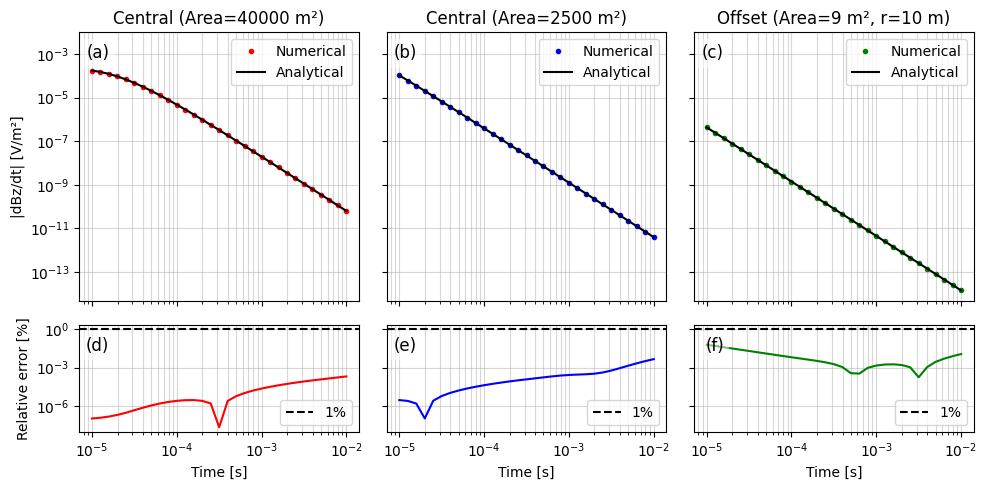

In [239]:
fig, axs = plt.subplots(2, 3, figsize=(10, 5), sharex=True, sharey='row',
                        gridspec_kw={'height_ratios': [2.5, 1]})

# Response panels
cases = [
    (dbdt_num_200, dbdt_ana_200, 'r.', f'Central (Area={A_200:.0f} m²)'),
    (dbdt_num_50,  dbdt_ana_50,  'b.', f'Central (Area={A_50:.0f} m²)'),
    (dbdt_offset_num, dbdt_offset_ana, 'g.', f'Offset (Area={A_3:.0f} m², r={r_ref} m)'),
]
errors = [rel_err_200, rel_err_50, rel_err_offset]
colors = ['r', 'b', 'g']

for j, (num, ana, marker, title) in enumerate(cases):
    axs[0, j].loglog(times, np.abs(num), marker, label='Numerical')
    axs[0, j].loglog(times, np.abs(ana), 'k-', label='Analytical')
    axs[0, j].set_title(title)
    axs[0, j].legend()
    axs[0, j].grid(True, which='both', alpha=0.5)

for j in range(3):
    axs[1, j].loglog(times, errors[j], f'{colors[j]}-')
    axs[1, j].axhline(1, color='k', ls='--', label='1%')
    axs[1, j].legend(loc='lower right')
    axs[1, j].grid(True, which='both', alpha=0.5)
    axs[1, j].set_xlabel('Time [s]')

axs[0, 0].set_ylabel('|dBz/dt| [V/m²]')
axs[1, 0].set_ylabel('Relative error [%]')
axs[0, 0].set_ylim(None, 1e-2)

fig.tight_layout()

def add_panel_labels(axs, n_cols=3, x_shift=[0.03], y_shift=[0.06]):
    n_rows = len(axs)
    if len(x_shift) == 1:
        x_shift = x_shift * n_rows
    if len(y_shift) == 1:
        y_shift = y_shift * n_rows
    letters = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
    x0s = [ax.get_position().x0 for ax in axs[0]]   # one per column
    y1s = [axs[r, 0].get_position().y1 for r in range(n_rows)]  # one per row
    for i, ax in enumerate(axs.flat):
        row, col = divmod(i, n_cols)
        fig.text(x0s[col] + x_shift[row], y1s[row] - y_shift[row], letters[i],
                fontsize=12, va='bottom', ha='right', 
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.5))
        
add_panel_labels(axs)

### Test 2 — Square loop vs circular equivalent

Compare the central square-loop response (area integral) against the circular-loop response using the equivalent radius $a_{eff} = L/\sqrt{\pi}$ (equal area). The difference quantifies the geometry effect between square and circular loop shapes.

In [243]:
# ============================================================================
# Test 2: Square loop vs circular equivalent
# ============================================================================

# --- Case 1: 200x200 central ---
L_200 = 200.0
a_200 = np.sqrt((L_200**2) / np.pi)
dbdt_sq_200 = fwd_square_central([], [rho_hs], L_200, times, n_quad=7)
dbdt_ci_200 = fwd_circle_central([], [rho_hs], a_200, times)
rel_200 = 100 * np.abs(dbdt_sq_200 - dbdt_ci_200) / np.maximum(np.abs(dbdt_sq_200), 1e-30)

# --- Case 2: 50x50 central ---
L_50 = 50.0
a_50 = np.sqrt((L_50**2) / np.pi)
dbdt_sq_50 = fwd_square_central([], [rho_hs], L_50, times, n_quad=9)
dbdt_ci_50 = fwd_circle_central([], [rho_hs], a_50, times)
rel_50 = 100 * np.abs(dbdt_sq_50 - dbdt_ci_50) / np.maximum(np.abs(dbdt_sq_50), 1e-30)

# --- Case 3: 3x3 offset ---
L_3 = 3.0
a_3 = np.sqrt((L_3**2) / np.pi)
rx_offset = 10.0
rx_x, rx_y = rx_offset, 0.0
dbdt_sq_3_off = fwd_square_offset([], [rho_hs], L_3, rx_x, rx_y, times, n_quad=13)
dbdt_ci_3_off = fwd_circle_offset([], [rho_hs], a_3, rx_offset, times)
rel_3_off = 100 * np.abs(dbdt_sq_3_off - dbdt_ci_3_off) / np.maximum(np.abs(dbdt_sq_3_off), 1e-30)

print("=== Comparison summary ===")
print(f"200x200 central: max Δ = {rel_200.max():.3f}% | mean Δ = {rel_200.mean():.3f}%")
print(f"50x50 central  : max Δ = {rel_50.max():.3f}% | mean Δ = {rel_50.mean():.3f}%")
print(f"3x3 offset     : max Δ = {rel_3_off.max():.3f}% | mean Δ = {rel_3_off.mean():.3f}% (r={rx_offset} m)")

=== Comparison summary ===
200x200 central: max Δ = 1.972% | mean Δ = 0.660%
50x50 central  : max Δ = 0.740% | mean Δ = 0.123%
3x3 offset     : max Δ = 0.003% | mean Δ = 0.001% (r=10.0 m)


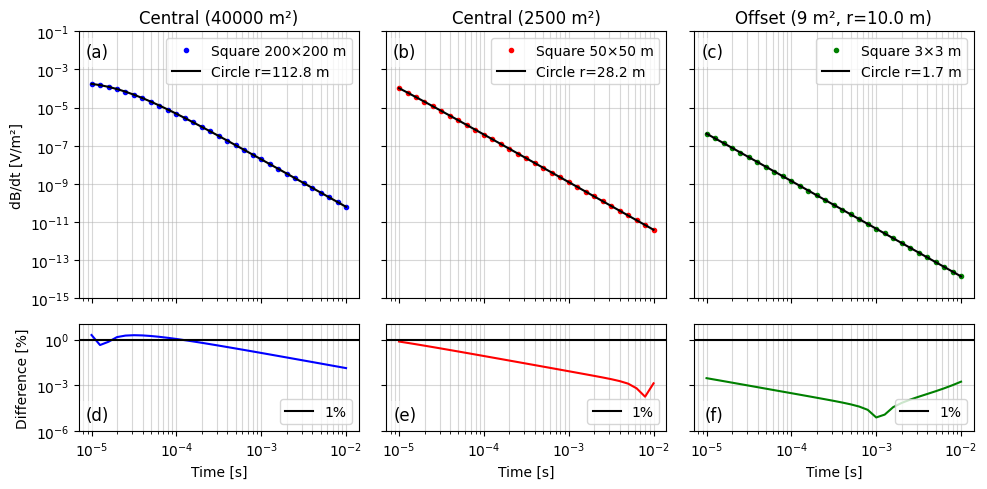

In [263]:
fig, axs = plt.subplots(2, 3, figsize=(10, 5), sharex=True, sharey='row',
                        gridspec_kw={'height_ratios': [2.5, 1]})

cases = [
    (dbdt_sq_200, dbdt_ci_200, rel_200, 'b', f'Square {L_200:.0f}×{L_200:.0f} m', f'Circle r={a_200:.1f} m', f'Central ({L_200**2:.0f} m²)'),
    (dbdt_sq_50,  dbdt_ci_50,  rel_50,  'r', f'Square {L_50:.0f}×{L_50:.0f} m', f'Circle r={a_50:.1f} m',  f'Central ({L_50**2:.0f} m²)'),
    (dbdt_sq_3_off, dbdt_ci_3_off, rel_3_off, 'g', f'Square {L_3:.0f}×{L_3:.0f} m', f'Circle r={a_3:.1f} m', f'Offset ({L_3**2:.0f} m², r={rx_offset} m)'),
]

for j, (sq, ref, rel, c, sq_lbl, ref_lbl, title) in enumerate(cases):
    axs[0, j].loglog(times, np.abs(sq), f'{c}.', lw=2, label=sq_lbl)
    axs[0, j].loglog(times, np.abs(ref), 'k-', lw=1.5, label=ref_lbl)
    axs[0, j].set_title(title)
    axs[0, j].legend()
    axs[0, j].grid(True, which='both', alpha=0.5)

    axs[1, j].loglog(times, rel, f'{c}-')
    axs[1, j].axhline(1, color='k', ls='-', label='1%')
    axs[1, j].set_xlabel('Time [s]')
    axs[1, j].legend(loc='lower right')
    axs[1, j].grid(True, which='both', alpha=0.5)

axs[0, 0].set_ylabel(r'dB/dt [V/m²]')
axs[1, 0].set_ylabel('Difference [%]')
axs[1, 1].set_ylim(1e-6, 10)
axs[0, 0].set_ylim(1e-15, 1e-1)

fig.tight_layout()

add_panel_labels(axs, y_shift=[0.06, 0.2])

### Test 3 — Layered models (central and offset loop)
Two- and three-layer models to check physically expected behaviour for both central and offset receiver positions.

In [245]:
# Model 1: low-high-low (10 / 100 / 10 Ohm.m, thicknesses 30, 20 m)
times = np.logspace(-5, -2, 31)
th1 = [30.0, 20.0]
rho1 = [10.0, 100.0, 10.0]
pytem_lhl_central = fwd_square_central(
    th1, rho1, L_50, times, n_quad=5,
    hankel_filter='key_101', fourier_filter='key_101'
)
pytem_lhl_offset = fwd_square_offset(
    th1, rho1, L_3, 10.0, 0.0, times, n_quad=5,
    hankel_filter='key_101', fourier_filter='key_101'
)

# Reference: AarhusInv (same 31 gate times)
aarhus_inv_lhl_central = np.array([
    7.749263e-04, 5.871443e-04, 4.271254e-04, 2.941576e-04,
    1.987840e-04, 1.300814e-04, 8.290166e-05, 5.142938e-05,
    3.088973e-05, 1.800577e-05, 1.016799e-05, 5.596638e-06,
    3.068655e-06, 1.627900e-06, 8.845018e-07, 4.805502e-07,
    2.641654e-07, 1.474779e-07, 8.327249e-08, 4.758555e-08,
    2.731165e-08, 1.571936e-08, 9.167189e-09, 5.228992e-09,
    3.042238e-09, 1.754475e-09, 1.009169e-09, 5.802100e-10,
    3.325352e-10, 1.906650e-10, 1.088946e-10])

aarhus_inv_lhl_offset = np.array([
    8.909462e-06, 5.534735e-06, 3.400043e-06, 2.015686e-06,
    1.206456e-06, 7.121532e-07, 4.165131e-07, 2.407902e-07,
    1.365293e-07, 7.600484e-08, 4.138204e-08, 2.213696e-08,
    1.188021e-08, 6.196162e-09, 3.325720e-09, 1.790114e-09,
    9.771045e-10, 5.425529e-10, 3.050211e-10, 1.737058e-10,
    9.941518e-11, 5.708730e-11, 3.323015e-11, 1.892443e-11,
    1.099644e-11, 6.335048e-12, 3.640742e-12, 2.091701e-12,
    1.198096e-12, 6.866033e-13, 3.919703e-13])

# Model 2: high-low-high (100 / 10 / 100 Ohm.m, same geometry)
th2 = [30.0, 20.0]
rho2 = [100.0, 10.0, 100.0]
pytem_hlh_central = fwd_square_central(
    th2, rho2, L_50, times, n_quad=3,
    hankel_filter='key_101', fourier_filter='key_101'
)
pytem_hlh_offset = fwd_square_offset(
    th2, rho2, L_3, 10.0, 0.0, times, n_quad=5,
    hankel_filter='key_101', fourier_filter='key_101'
)

aarhus_inv_hlh_central = np.array([
    8.272315e-05, 5.190274e-05, 3.479861e-05, 2.416104e-05,
    1.762117e-05, 1.301000e-05, 9.569980e-06, 6.896801e-06,
    4.807463e-06, 3.231898e-06, 2.085133e-06, 1.292234e-06,
    7.797680e-07, 4.444820e-07, 2.505580e-07, 1.362780e-07,
    7.227618e-08, 3.765000e-08, 1.929029e-08, 9.805497e-09,
    4.939895e-09, 2.478716e-09, 1.262451e-09, 6.272540e-10,
    3.213085e-10, 1.641116e-10, 8.432066e-11, 4.371778e-11,
    2.279963e-11, 1.200644e-11, 6.349225e-12])

aarhus_inv_hlh_offset = np.array([
    3.640381e-07, 2.263633e-07, 1.504536e-07, 1.032424e-07,
    7.422265e-08, 5.386947e-08, 3.889692e-08, 2.751781e-08,
    1.884899e-08, 1.247316e-08, 7.936371e-09, 4.860343e-09,
    2.904472e-09, 1.641974e-09, 9.197265e-10, 4.977077e-10,
    2.629333e-10, 1.365618e-10, 6.981305e-11, 3.542850e-11,
    1.782658e-11, 8.936757e-12, 4.548541e-12, 2.258713e-12,
    1.156518e-12, 5.904800e-13, 3.032834e-13, 1.571915e-13,
    8.195089e-14, 4.314070e-14, 2.280462e-14])

# Percentage differences vs AarhusInv
pct_aarhus_lhl_central = 100 * np.abs(np.abs(pytem_lhl_central) - np.abs(aarhus_inv_lhl_central)) / np.maximum(np.abs(pytem_lhl_central), 1e-30)
pct_aarhus_lhl_offset = 100 * np.abs(np.abs(pytem_lhl_offset) - np.abs(aarhus_inv_lhl_offset)) / np.maximum(np.abs(pytem_lhl_offset), 1e-30)
pct_aarhus_hlh_central = 100 * np.abs(np.abs(pytem_hlh_central) - np.abs(aarhus_inv_hlh_central)) / np.maximum(np.abs(pytem_hlh_central), 1e-30)
pct_aarhus_hlh_offset = 100 * np.abs(np.abs(pytem_hlh_offset) - np.abs(aarhus_inv_hlh_offset)) / np.maximum(np.abs(pytem_hlh_offset), 1e-30)

print(f"LHL central: max diff vs AarhusInv = {pct_aarhus_lhl_central.max():.2f}%")
print(f"LHL offset : max diff vs AarhusInv = {pct_aarhus_lhl_offset.max():.2f}%")
print(f"HLH central: max diff vs AarhusInv = {pct_aarhus_hlh_central.max():.2f}%")
print(f"HLH offset : max diff vs AarhusInv = {pct_aarhus_hlh_offset.max():.2f}%")

LHL central: max diff vs AarhusInv = 0.84%
LHL offset : max diff vs AarhusInv = 0.85%
HLH central: max diff vs AarhusInv = 0.90%
HLH offset : max diff vs AarhusInv = 0.84%


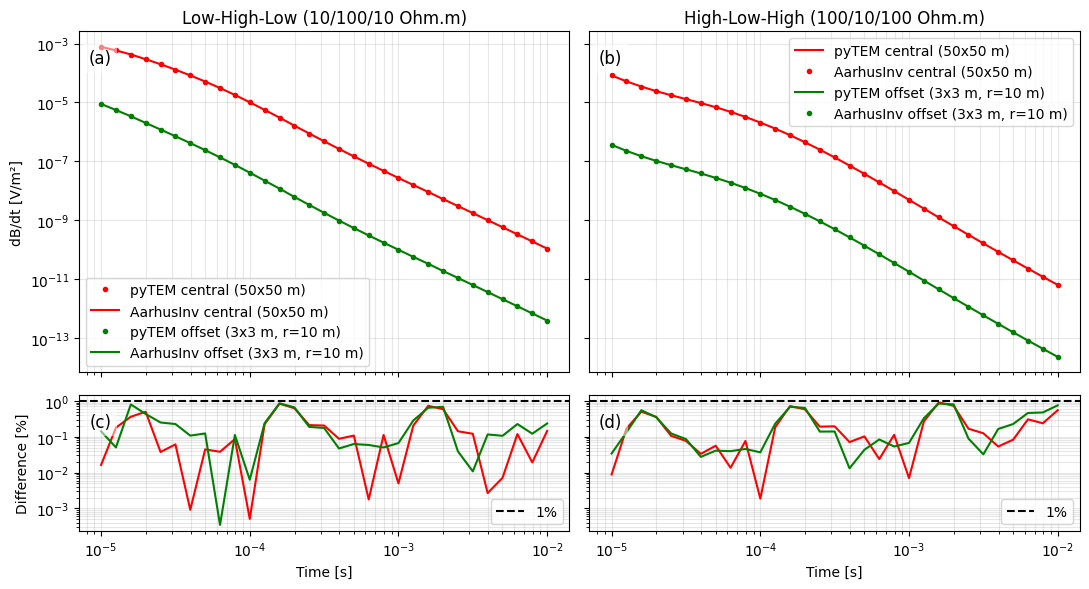

In [266]:
fig, axs = plt.subplots(2, 2, figsize=(11, 6), sharex=True, sharey='row',
                        gridspec_kw={'height_ratios': [2.5, 1]})

# LHL model: central and offset responses
axs[0, 0].loglog(times, np.abs(pytem_lhl_central), 'r.', label='pyTEM central (50x50 m)')
axs[0, 0].loglog(times, np.abs(aarhus_inv_lhl_central), 'r-', ms=3, label='AarhusInv central (50x50 m)')
axs[0, 0].loglog(times, np.abs(pytem_lhl_offset), 'g.', label='pyTEM offset (3x3 m, r=10 m)')
axs[0, 0].loglog(times, np.abs(aarhus_inv_lhl_offset), 'g-', ms=3, label='AarhusInv offset (3x3 m, r=10 m)')
axs[0, 0].set_title('Low-High-Low (10/100/10 Ohm.m)')
axs[0, 0].set_ylabel(r'dB/dt [V/m²]')
axs[0, 0].legend()
axs[0, 0].grid(True, which='both', alpha=0.3)

axs[1, 0].loglog(times, pct_aarhus_lhl_central, 'r-')
axs[1, 0].loglog(times, pct_aarhus_lhl_offset, 'g-')
axs[1, 0].axhline(1, color='k', ls='--', label='1%')
axs[1, 0].set_ylabel('Difference [%]')
axs[1, 0].set_xlabel('Time [s]')
axs[1, 0].legend(loc='lower right')
axs[1, 0].grid(True, which='both', alpha=0.3)

# HLH model: central and offset responses
axs[0, 1].loglog(times, np.abs(pytem_hlh_central), 'r-', label='pyTEM central (50x50 m)')
axs[0, 1].loglog(times, np.abs(aarhus_inv_hlh_central), 'ro', ms=3, label='AarhusInv central (50x50 m)')
axs[0, 1].loglog(times, np.abs(pytem_hlh_offset), 'g-', label='pyTEM offset (3x3 m, r=10 m)')
axs[0, 1].loglog(times, np.abs(aarhus_inv_hlh_offset), 'go', ms=3, label='AarhusInv offset (3x3 m, r=10 m)')
axs[0, 1].set_title('High-Low-High (100/10/100 Ohm.m)')
axs[0, 1].legend()
axs[0, 1].grid(True, which='both', alpha=0.3)

axs[1, 1].loglog(times, pct_aarhus_hlh_central, 'r-')
axs[1, 1].loglog(times, pct_aarhus_hlh_offset, 'g-')
axs[1, 1].axhline(1, color='k', ls='--', label='1%')
axs[1, 1].set_xlabel('Time [s]')
axs[1, 1].grid(True, which='both', alpha=0.3)
axs[1, 1].legend(loc='lower right')

fig.tight_layout()
add_panel_labels(axs, n_cols=2)

### Test 4 — Waveform convolution and system filter effects

Compare the ideal step-off response with linear ramp-off waveforms (1 µs, 5 µs, 20 µs) and Butterworth low-pass filter effects.

In [247]:
t_fine = np.logspace(np.log10(5e-6), np.log10(2e-2), 151)
step_fine = fwd_circle_central([], [rho_hs], a_50, t_fine)

ramp_durations = [1e-6, 5e-6, 20e-6]  # 1, 5, 20 µs
dbdt_ramp = {}
for T_ramp in ramp_durations:
    wf_t = np.array([-T_ramp, 0.0])
    wf_I = np.array([1.0, 0.0])
    dbdt_ramp[T_ramp] = convolve_waveform(t_fine, step_fine, wf_t, wf_I, times)

print(f"  Waveform convolution done ({rho_hs} Ohm.m half-space).")
for T_ramp in ramp_durations:
    ratio = np.abs(dbdt_ramp[T_ramp][0] / dbdt_num_50[0])
    print(f"  T_ramp = {T_ramp*1e6:.0f} µs: early-time ratio = {ratio:.4f}")
    ratio = np.abs(dbdt_ramp[T_ramp][-1] / dbdt_num_50[-1])
    print(f"  T_ramp = {T_ramp*1e6:.0f} µs: late-time ratio = {ratio:.4f}")

  Waveform convolution done (100.0 Ohm.m half-space).
  T_ramp = 1 µs: early-time ratio = 0.8963
  T_ramp = 1 µs: late-time ratio = 1.0022
  T_ramp = 5 µs: early-time ratio = 0.6261
  T_ramp = 5 µs: late-time ratio = 1.0017
  T_ramp = 20 µs: early-time ratio = 0.2846
  T_ramp = 20 µs: late-time ratio = 0.9998


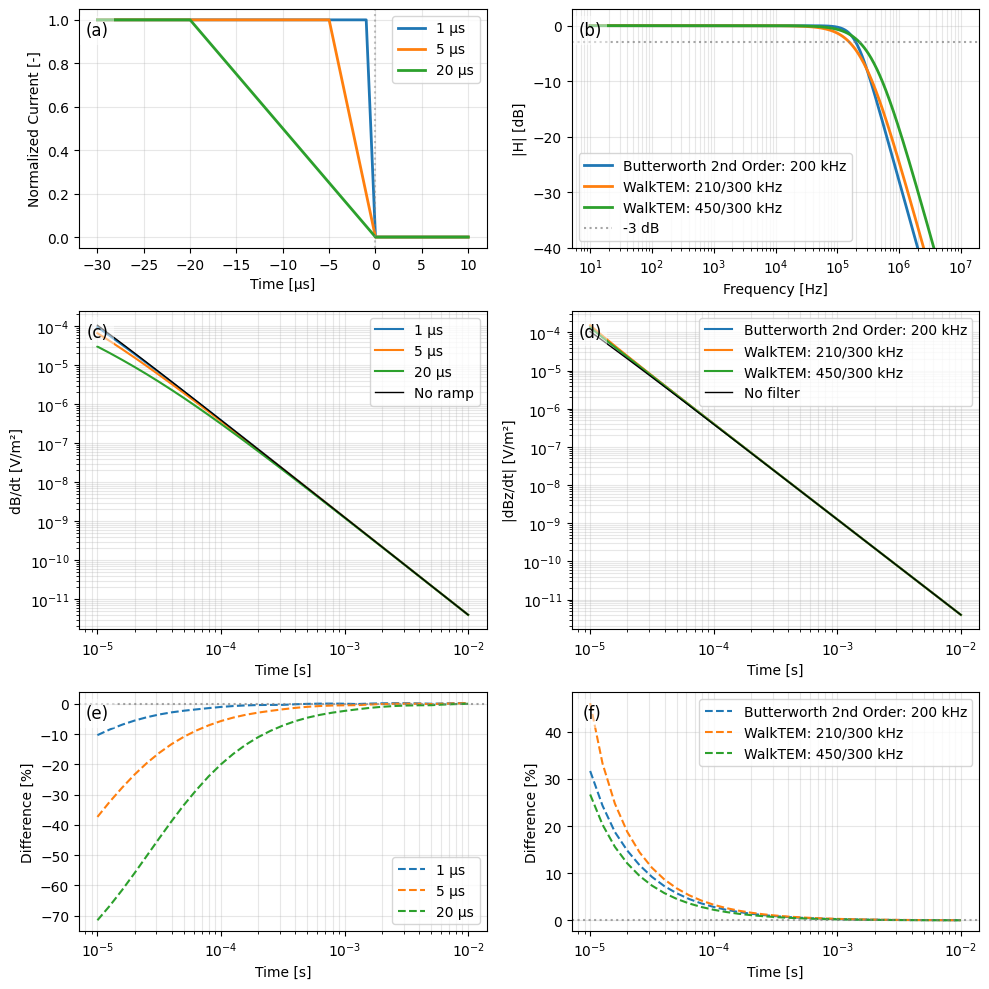

In [260]:
fig, axs = plt.subplots(3, 2, figsize=(10, 10), gridspec_kw={'height_ratios': [1.5, 2, 1.5]})
ramp_colors = ['C0', 'C1', 'C2']

# (a) Waveform shapes
max_ramp = max(ramp_durations)
for T, c in zip(ramp_durations, ramp_colors):
    t_wf = np.array([-1.5*max_ramp, -T, 0, 0.5*max_ramp]) * 1e6
    axs[0, 0].plot(t_wf, [1, 1, 0, 0], c=c, lw=2, label=f'{T*1e6:.0f} µs')
axs[0, 0].axvline(0, color='gray', ls=':', alpha=0.5)
axs[0, 0].set(xlabel='Time [µs]', ylabel='Normalized Current [-]')
axs[0, 0].legend(); axs[0, 0].grid(True, alpha=0.3)

# (b) Convolved responses
for T, c in zip(ramp_durations, ramp_colors):
    axs[1, 0].loglog(times, np.abs(dbdt_ramp[T]), c=c, lw=1.5, label=f'{T*1e6:.0f} µs')
axs[1, 0].loglog(times, np.abs(dbdt_num_50), 'k-', lw=1, label='No ramp')
axs[1, 0].set(xlabel='Time [s]', ylabel=r'dB/dt [V/m²]')
axs[1, 0].legend(); axs[1, 0].grid(True, which='both', alpha=0.3)

# (c) Ramp-off % change vs step-off
for T, c in zip(ramp_durations, ramp_colors):
    pct = 100 * (np.abs(dbdt_ramp[T]) - np.abs(dbdt_num_50)) / np.abs(dbdt_num_50)
    axs[2, 0].semilogx(times, pct, c=c, ls='--', label=f'{T*1e6:.0f} µs')
axs[2, 0].axhline(0, color='gray', ls=':', alpha=0.7)
axs[2, 0].set(xlabel='Time [s]', ylabel='Difference [%]')
axs[2, 0].legend(); axs[2, 0].grid(True, which='both', alpha=0.3)

filt_configs = [
    ('Butterworth 2nd Order: 200 kHz',   butterworth_filter(f_high=200e3, order=2)),
    ('WalkTEM: 210/300 kHz',  cascade_filter(210e3)),
    ('WalkTEM: 450/300 kHz',  cascade_filter(450e3)),
]
filt_colors = ['C0', 'C1', 'C2']

dbdt_filtered = {}
for label, filt in filt_configs:
    dbdt_filtered[label] = fwd_circle_central([], [rho_hs], a_50, times,
                                               system_filter=filt)
    
# (d) Filter frequency response
freqs = np.logspace(1, 7, 500)
omega_arr = 2 * np.pi * freqs
for (label, filt), c in zip(filt_configs, filt_colors):
    axs[0, 1].semilogx(freqs, 20*np.log10(np.abs(filt(omega_arr))),
                        c=c, lw=2, label=label)
axs[0, 1].axhline(-3, color='gray', ls=':', alpha=0.7, label='-3 dB')
axs[0, 1].set(xlabel='Frequency [Hz]', ylabel='|H| [dB]',
               ylim=(-40, 3))
axs[0, 1].legend(); axs[0, 1].grid(True, which='both', alpha=0.3)

# (e) Filtered response
for (label, _), c in zip(filt_configs, filt_colors):
    axs[1, 1].loglog(times, np.abs(dbdt_filtered[label]), c=c, lw=1.5, label=label)
axs[1, 1].loglog(times, np.abs(dbdt_num_50), 'k-', lw=1, label='No filter')
axs[1, 1].set(xlabel='Time [s]', ylabel=r'|dBz/dt| [V/m²]')
axs[1, 1].legend(); axs[1, 1].grid(True, which='both', alpha=0.3)

# (f) Filter % change
for (label, _), c in zip(filt_configs, filt_colors):
    pct = 100 * (np.abs(dbdt_filtered[label]) - np.abs(dbdt_num_50)) / np.abs(dbdt_num_50)
    axs[2, 1].semilogx(times, pct, c=c, ls='--', label=label)
axs[2, 1].axhline(0, color='gray', ls=':', alpha=0.7)
axs[2, 1].set(xlabel='Time [s]', ylabel='Difference [%]')
axs[2, 1].legend(); axs[2, 1].grid(True, which='both', alpha=0.3)

fig.tight_layout()

add_panel_labels(axs, n_cols=2, y_shift=[0.03, 0.03, 0.03], 
                 x_shift=[0.03, 0.03, 0.03])

### Test 5 — IP effect (single-layer complex resistivity)

Compare the TEM response using three IP formulations in a **single-layer** model:

- **Pelton** (1978): $\;\rho(\omega) = \rho_0 \left[1 - m\left(1 - \frac{1}{1 + (j\omega\tau)^c}\right)\right]$
- **Double Pelton**: $\;\rho(\omega) = \rho_0\left[1 - m_1\left(1 - \frac{1}{1 + (j\omega\tau_1)^{c_1}}\right) - m_2\left(1 - \frac{1}{1 + (j\omega\tau_2)^{c_2}}\right)\right]$
- **Cole-Cole** (1941): $\;\sigma(\omega) = \sigma_\infty + \frac{\sigma_0 - \sigma_\infty}{1 + (j\omega\tau)^c}$

The figure shows three panels: $|\partial B_z/\partial t|$, $\mathrm{Re}(\sigma^*)$, and $\mathrm{Im}(\sigma^*)$.

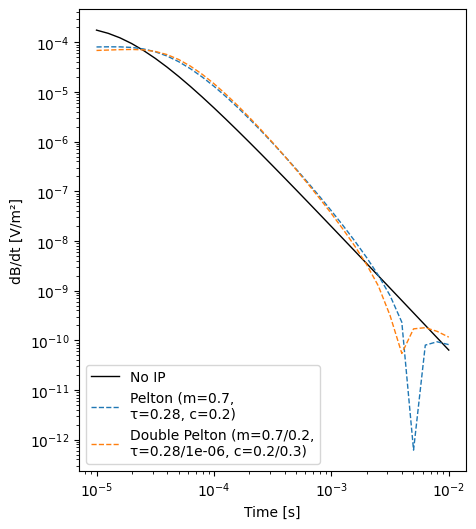

In [290]:
# --- IP model functions ---

def pelton_res_rho(rho_0, m, tau, c, omega):
    """Pelton et al. (1978) complex resistivity."""
    iotc = (1j * omega * tau) ** c
    return rho_0 * (1 - m * (1 - 1 / (1 + iotc)))

def cole_cole_rho(rho_0, cond_0, cond_inf, tau, c, omega):
    """Cole-Cole (1941) conductivity formulation, returned as resistivity."""
    iotc = (1j * omega * tau) ** c
    return 1.0 / (cond_inf + (cond_0 - cond_inf) / (1 + iotc))

def double_pelton_rho(rho_0, m1, tau1, c1, m2, tau2, c2, omega):
    """Double Pelton — two relaxation terms."""
    r1 = m1 * (1 - 1 / (1 + (1j * omega * tau1)**c1))
    r2 = m2 * (1 - 1 / (1 + (1j * omega * tau2)**c2))
    return rho_0 * (1 - r1 - r2)

# --- TEM forward model with pluggable IP per layer ---

def tem_forward_ip(thicknesses, resistivities, tx_radius, times,
                   ip_funcs=None, current=1.0, system_filter=None):
    """
    Central-loop step-off dBz/dt with arbitrary IP model per layer.

    ip_funcs : list of callables (one per layer), each f(rho_0, omega) -> complex rho.
               Use None for layers without IP.
    """
    thicknesses = np.asarray(thicknesses, dtype=float)
    rho_dc = np.asarray(resistivities, dtype=float)
    times = np.asarray(times, dtype=float)
    a_r = float(tx_radius)
    n_layers = len(rho_dc)
    if ip_funcs is None:
        ip_funcs = [None] * n_layers

    def _hz_sec(omega):
        rho_complex = np.array([
            ip_funcs[j](rho_dc[j], omega) if ip_funcs[j] is not None
            else complex(rho_dc[j]) for j in range(n_layers)])
        lam = _HANKEL_BASE_201 / a_r
        r_te = te_reflection_coeff(lam, omega, thicknesses, rho_complex)
        hz = 0.5 * a_r * np.dot(r_te * lam, _HANKEL_J1_201) / a_r
        if system_filter is not None:
            hz *= system_filter(omega)
        return hz

    dbdt = np.zeros(len(times))
    for i, t in enumerate(times):
        omega_pts = _FOURIER_BASE_81 / t
        sig = np.array([MU0 * np.imag(_hz_sec(w)) for w in omega_pts])
        dbdt[i] = np.dot(sig, _FOURIER_SIN_81) / t
    dbdt *= current * 2.0 / np.pi
    return dbdt


# --- Single-layer model: 100 Ohm.m half-space with IP ---

thick_ip = []
rho_ip = [100.0]
rho0 = rho_ip[0]

# Pelton parameters
m, tau, c = 0.7, 0.28, 0.2

# Double-Pelton parameters
m1, tau1, c1 = m, tau, c
m2, tau2, c2 = 0.2, 1e-6, 0.3

# Cole-Cole parameters mapped to match Pelton trend (rho decreases with frequency)
cond_0 = 1.0 / rho0
cond_inf = cond_0 / (1 - m)

ip_models = {
    'No IP': None,
    f'Pelton (m={m},\nτ={tau}, c={c})': (
        lambda r0, w, _m=m, _tau=tau, _c=c: pelton_res_rho(r0, _m, _tau, _c, w)
    ),
    f'Double Pelton (m={m1}/{m2},\nτ={tau1}/{tau2}, c={c1}/{c2})': (
        lambda r0, w, _m1=m1, _t1=tau1, _c1=c1, _m2=m2, _t2=tau2, _c2=c2:
        double_pelton_rho(r0, _m1, _t1, _c1, _m2, _t2, _c2, w)
    ),
}

# Forward responses and complex resistivity/conductivity spectra
freqs = 1.0 / (2.0 * np.pi * times)  # Hz, common mapping for TEM gate time t

freqs = np.logspace(-3, 4, 200)
omega_arr = 2 * np.pi * freqs

dbdt_ip = {}
rho_w_models = {}
sigma_w_models = {}
for label, ip_fun in ip_models.items():
    dbdt_ip[label] = tem_forward_ip(thick_ip, rho_ip, a_200, times, ip_funcs=[ip_fun])
    if ip_fun is None:
        rho_w_models[label] = np.full_like(omega_arr, rho0, dtype=complex)
    else:
        rho_w_models[label] = np.array([ip_fun(rho0, w) for w in omega_arr])
    sigma_w_models[label] = 1.0 / rho_w_models[label]

# --- Plot: dB/dt, real conductivity, and imaginary conductivity ---
fig, ax = plt.subplots(1, 1, figsize=(5, 6))

ip_colors = ['k', 'C0', 'C1', 'C2']

for (label, _), ci in zip(ip_models.items(), ip_colors):
    ls = '-' if label == 'No IP' else '--'
    lw = 1 
    ax.loglog(times, np.abs(dbdt_ip[label]), c=ci, ls=ls, lw=lw, label=label)

ax.set(xlabel='Time [s]', ylabel=r'dB/dt [V/m²]')

ax.legend()

In [ ]:
ax_td.set(xlabel='Time [s]', ylabel=r'|dBz/dt| [V/m²]', title='TEM response')
ax_td.legend()
ax_td.grid(True, which='both', alpha=0.3)

for (label, _), ci in zip(ip_models.items(), ip_colors):
    ax_re.semilogx(freqs, np.real(sigma_w_models[label])*1000, c=ci, lw=1, label=label)

ax_re.set(xlabel='Frequency [Hz]', ylabel=r"$\sigma$ ' [mS/m]", title='Real conductivity')
ax_re.grid(True, which='both', alpha=0.3)

for (label, _), ci in zip(ip_models.items(), ip_colors):
    ax_im.semilogx(freqs, np.imag(sigma_w_models[label])*1000, c=ci, lw=1, label=label)

ax_im.axhline(0.0, color='gray', ls=':', lw=1)
ax_im.set(xlabel='Frequency [Hz]', ylabel=r"$\sigma$ '' [mS/m]", title='Imaginary conductivity')
ax_im.grid(True, which='both', alpha=0.3)

ax_im.axvline( 1.0 / (2.0 * np.pi * times[1]), c='k', ls='--', lw=1, label='Early time')
ax_im.axvline( 1.0 / (2.0 * np.pi * times[-1]), c='k', ls='--', lw=1, label='Late time')
